#NFL Research

This notebook contains my work for the first week of work with professor Ron Yurko at Carnegie Mellon's Sports Analytics Center.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request  # Used if your images are web URLs
from PIL import Image

pd.set_option('display.max_columns', 250)
pd.set_option('display.min_rows', 10)

## NFL Verse Stats

In [13]:
pip install nflreadpy

In [14]:
import pandas as pd
import nflreadpy as nfl

In [15]:
pbp = nfl.load_pbp().to_pandas() # play-by-play data
player_stats = nfl.load_player_stats().to_pandas() # player game or season statistics
team_stats = nfl.load_team_stats().to_pandas() # team game or season statistics
# schedules = nfl.load_schedules().to_pandas() # game schedules and results
players = nfl.load_players().to_pandas() # player information
rosters = nfl.load_rosters().to_pandas() # team rosters
rosters_weekly = nfl.load_rosters_weekly().to_pandas() # team rosters by season-week
snap_counts = nfl.load_snap_counts().to_pandas() # snap counts
nextgen_stats = nfl.load_nextgen_stats().to_pandas() # advanced stats from nextgenstats.nfl.com
ftn_charting = nfl.load_ftn_charting().to_pandas() # charted stats from ftnfantasy.com/data
participation = nfl.load_participation().to_pandas() # participation data (historical)
draft_picks = nfl.load_draft_picks().to_pandas() # nfl draft picks
injuries = nfl.load_injuries().to_pandas() # injury statuses and practice participation
contracts = nfl.load_contracts().to_pandas() # historical contract data from OTC
officials = nfl.load_officials().to_pandas() # officials for each game
combine = nfl.load_combine().to_pandas() # nfl combine results
depth_charts = nfl.load_depth_charts().to_pandas() # depth charts
trades = nfl.load_trades().to_pandas() # trades
ff_playerids = nfl.load_ff_playerids().to_pandas() # ffverse/dynastyprocess player ids
ff_rankings = nfl.load_ff_rankings().to_pandas() # fantasypros rankings
ff_opportunity = nfl.load_ff_opportunity().to_pandas() # expected yards, touchdowns, and fantasy points

##Madden Stats

In [16]:
madden2026 = pd.read_csv("/content/drive/MyDrive/ipynb stuff/Madden_Ratings.csv")
posS = player_stats["position"].unique()
posM = madden2026["Position"].unique()
posS, posM

position_mapping = {
    # Offense
    'Quarterback': 'QB',
    'Halfback': 'RB',
    'Fullback': 'FB',
    'Wide Receiver': 'WR',
    'Tight End': 'TE',
    'Left Tackle': 'OT',
    'Right Tackle': 'OT',
    'Left Guard': 'G',
    'Right Guard': 'G',
    'Center': 'C',

    # Defense
    'Left Edge': 'DE',       # Often grouped as DE/OLB edge rushers
    'Right Edge': 'DE',
    'Defensive Tackle': 'DT',
    'Mike Backer': 'MLB',
    'Sam Backer': 'OLB',      # Strong-side outside linebacker
    'Weak Backer': 'OLB',     # Weak-side outside linebacker
    'Cornerback': 'CB',
    'Free Safety': 'FS',
    'Strong Safety': 'S',     # Or 'SAF' depending on your roster dataset

    # Special Teams
    'Kicker': 'K',
    'Punter': 'P',
    'Long Snapper': 'LS'
}

team_mapping = {
    'Cincinnati Bengals': 'CIN',
    'Buffalo Bills': 'BUF',
    'Philadelphia Eagles': 'PHI',
    'Cleveland Browns': 'CLE',
    'New England Patriots': 'NE',
    'San Francisco 49ers': 'SF',
    'Detroit Lions': 'DET',
    'Los Angeles Rams': 'LA',
    'Green Bay Packers': 'GB',
    'Las Vegas Raiders': 'LV',
    'Denver Broncos': 'DEN',
    'Arizona Cardinals': 'ARI',
    'Carolina Panthers': 'CAR',
    'Chicago Bears': 'CHI',
    'Indianapolis Colts': 'IND',
    'Atlanta Falcons': 'ATL',
    'Pittsburgh Steelers': 'PIT',
    'Kansas City Chiefs': 'KC',
    'Seattle Seahawks': 'SEA',
    'Tennessee Titans': 'TEN',
    'Tampa Bay Buccaneers': 'TB',
    'Baltimore Ravens': 'BAL',
    'Minnesota Vikings': 'MIN',
    'Washington Commanders': 'WAS',
    'Houston Texans': 'HOU',
    'NY Giants': 'NYG',
    'Dallas Cowboys': 'DAL',
    'Los Angeles Chargers': 'LAC',
    'Miami Dolphins': 'MIA',
    'New Orleans Saints': 'NO',
    'Jacksonville Jaguars': 'JAX',
    'NY Jets': 'NYJ'
}

madden2026["position"] = madden2026["Position"].map(position_mapping)
madden2026 = madden2026.drop("Position", axis=1)
Name = madden2026["First Name"] + " " + madden2026["Last Name"]
madden = madden2026.drop(["First Name", "Last Name"], axis=1)
madden.insert(0, "Name", Name)
madden["Team"] = madden["Team"].map(team_mapping)
temp = madden["position"]
madden = madden.drop("position", axis = 1)
madden.insert(1, "position", temp)
madden.head()

,Name,position,Team,Overall,Player Image,Team Logo,ACCELERATION,AGILITY,JUMPING,STAMINA,STRENGTH,AWARENESS,BCVISION,BLOCKSHEDDING,BREAKSACK,BREAKTACKLE,CARRYING,CATCHINTRAFFIC,CATCHING,CHANGEOFDIRECTION,DEEPROUTERUNNING,FINESSEMOVES,HITPOWER,IMPACTBLOCKING,INJURY,JUKEMOVE,KICKACCURACY,KICKPOWER,KICKRETURN,LEADBLOCK,MANCOVERAGE,MEDIUMROUTERUNNING,OVERALL,PASSBLOCK,PASSBLOCKFINESSE,PASSBLOCKPOWER,PLAYACTION,PLAYRECOGNITION,POWERMOVES,PRESS,PURSUIT,RELEASE,RUNBLOCK,RUNBLOCKFINESSE,RUNBLOCKPOWER,RUNNINGSTYLE,SHORTROUTERUNNING,SPECTACULARCATCH,SPEED,SPINMOVE,STIFFARM,TACKLE,THROWACCURACYDEEP,THROWACCURACYMID,THROWACCURACYSHORT,THROWONTHERUN,THROWPOWER,THROWUNDERPRESSURE,TOUGHNESS,TRUCKING,ZONECOVERAGE
0,Ja'Marr Chase,WR,CIN,99,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/5oemvWKqCFgB...,94,92,98,96,73,99,98,37,29,88,71,94,98,97,98,10,27,46,92,90,17,24,60,27,13,97,99,37,20,26,10,17,10,15,36,99,53,27,31,Default,96,97,95,83,76,39,10,15,20,19,33,22,88,71,17
1,Josh Allen,QB,BUF,99,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/212FXcpkDUjs...,91,85,92,98,81,97,97,23,98,86,63,20,40,82,13,9,11,26,99,81,14,22,13,17,12,15,99,14,10,15,97,15,9,9,33,18,17,10,10,Default Stride Bread Loaf,22,23,88,78,83,32,90,88,97,99,98,94,98,76,18
2,Lane Johnson,OT,PHI,99,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/1Nt5pFCpjcBc...,78,75,82,88,93,99,60,56,39,30,67,58,64,58,25,60,60,95,84,54,22,25,10,96,12,33,99,98,94,98,39,29,53,10,55,45,97,96,98,Default,46,57,77,50,55,60,50,54,59,52,65,41,91,65,20
3,Myles Garrett,DE,CLE,99,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/4qbblHggBjaH...,90,86,94,89,96,97,39,96,12,34,55,21,52,71,4,93,84,90,92,36,20,20,10,17,51,8,99,45,45,45,10,94,99,44,97,31,45,45,45,Long Stride Default,15,25,87,40,48,92,27,30,31,23,55,16,87,36,51
4,Christian Gonzalez,CB,NE,98,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/6Z0rWjQfkWgv...,93,94,95,90,59,98,75,53,10,67,60,62,74,95,20,37,49,48,90,74,42,46,55,15,98,27,98,30,24,25,6,98,28,86,77,40,32,27,32,Default Stride Loose,37,73,96,66,57,76,6,10,15,10,35,10,78,42,90


In [17]:
seen = set()
seen_again = set()

for player in list(madden["Name"]):
    if player not in seen:
        seen.add(player)
    else:
        if player in seen:
            seen_again.add(player)

seen_again

{'Aaron Brewer',
 'Byron Young',
 'Jaylon Jones',
 'Jonah Williams',
 'Jordan Phillips'}

In [18]:
duplicateNames = madden[madden["Name"].duplicated(keep=False)].sort_values("Name")["Name"].unique()
madden_duplicates = madden[madden["Name"].duplicated(keep=False)].sort_values("Name")
madden_duplicates.head()

,Name,position,Team,Overall,Player Image,Team Logo,ACCELERATION,AGILITY,JUMPING,STAMINA,STRENGTH,AWARENESS,BCVISION,BLOCKSHEDDING,BREAKSACK,BREAKTACKLE,CARRYING,CATCHINTRAFFIC,CATCHING,CHANGEOFDIRECTION,DEEPROUTERUNNING,FINESSEMOVES,HITPOWER,IMPACTBLOCKING,INJURY,JUKEMOVE,KICKACCURACY,KICKPOWER,KICKRETURN,LEADBLOCK,MANCOVERAGE,MEDIUMROUTERUNNING,OVERALL,PASSBLOCK,PASSBLOCKFINESSE,PASSBLOCKPOWER,PLAYACTION,PLAYRECOGNITION,POWERMOVES,PRESS,PURSUIT,RELEASE,RUNBLOCK,RUNBLOCKFINESSE,RUNBLOCKPOWER,RUNNINGSTYLE,SHORTROUTERUNNING,SPECTACULARCATCH,SPEED,SPINMOVE,STIFFARM,TACKLE,THROWACCURACYDEEP,THROWACCURACYMID,THROWACCURACYSHORT,THROWONTHERUN,THROWPOWER,THROWUNDERPRESSURE,TOUGHNESS,TRUCKING,ZONECOVERAGE
169,Aaron Brewer,C,MIA,85,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/1rcCzp9f3OyZ...,63,62,72,84,85,94,25,18,12,12,22,15,31,54,15,15,15,74,86,25,12,14,10,91,15,15,85,82,82,79,6,15,22,10,24,25,91,93,87,Default Stride Awkward,27,20,74,30,31,31,6,6,6,6,12,13,84,27,17
1923,Aaron Brewer,LS,ARI,62,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/5NdzvrqrP3cl...,72,69,68,77,68,60,39,59,15,20,50,45,55,63,37,35,50,68,87,35,13,13,10,53,28,42,62,57,40,50,6,35,51,25,61,22,51,34,39,Default,47,40,73,40,55,58,6,6,6,6,14,10,69,50,32
206,Byron Young,DE,LA,84,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/wS8JnLBEBj9e...,93,77,90,84,74,86,60,78,14,54,61,46,53,65,29,80,83,71,90,56,11,13,45,35,47,34,84,40,40,40,6,88,85,47,87,25,45,45,45,Default Stride Loose,41,47,92,49,53,87,6,6,6,6,25,9,80,55,54
1346,Byron Young,DT,PHI,69,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/1Nt5pFCpjcBc...,81,59,66,76,82,69,21,75,12,15,40,22,37,49,5,57,79,78,93,29,11,14,10,24,15,7,69,35,35,35,8,70,68,25,76,29,40,40,40,Default Stride Awkward,10,23,71,25,35,80,6,6,7,9,10,10,82,25,23
956,Jaylon Jones,CB,IND,73,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/5yTvAS7xG5Z8...,93,87,90,92,62,75,72,52,16,63,63,62,67,81,33,44,75,51,87,69,13,15,60,15,71,37,73,25,25,25,6,75,35,75,75,49,35,35,35,Default Stride Loose,39,67,89,64,52,61,11,13,17,19,33,15,80,48,74


In [19]:
# print(rosters[["full_name", "position", "gsis_id", "team"]].isna().sum())
rosters_small = rosters[["full_name", "gsis_id", "team"]]

rosters_small_duplicates = rosters_small[rosters_small["full_name"].isin(duplicateNames)]
rosters_small_duplicates.head()

duplicates_merged = madden_duplicates.merge(rosters_small_duplicates, left_on=["Name", "Team"], right_on=["full_name","team"] , how="left")
duplicates_merged

,Name,position,Team,Overall,Player Image,Team Logo,ACCELERATION,AGILITY,JUMPING,STAMINA,STRENGTH,AWARENESS,BCVISION,BLOCKSHEDDING,BREAKSACK,BREAKTACKLE,CARRYING,CATCHINTRAFFIC,CATCHING,CHANGEOFDIRECTION,DEEPROUTERUNNING,FINESSEMOVES,HITPOWER,IMPACTBLOCKING,INJURY,JUKEMOVE,KICKACCURACY,KICKPOWER,KICKRETURN,LEADBLOCK,MANCOVERAGE,MEDIUMROUTERUNNING,OVERALL,PASSBLOCK,PASSBLOCKFINESSE,PASSBLOCKPOWER,PLAYACTION,PLAYRECOGNITION,POWERMOVES,PRESS,PURSUIT,RELEASE,RUNBLOCK,RUNBLOCKFINESSE,RUNBLOCKPOWER,RUNNINGSTYLE,SHORTROUTERUNNING,SPECTACULARCATCH,SPEED,SPINMOVE,STIFFARM,TACKLE,THROWACCURACYDEEP,THROWACCURACYMID,THROWACCURACYSHORT,THROWONTHERUN,THROWPOWER,THROWUNDERPRESSURE,TOUGHNESS,TRUCKING,ZONECOVERAGE,full_name,gsis_id,team
0,Aaron Brewer,C,MIA,85,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/1rcCzp9f3OyZ...,63,62,72,84,85,94,25,18,12,12,22,15,31,54,15,15,15,74,86,25,12,14,10,91,15,15,85,82,82,79,6,15,22,10,24,25,91,93,87,Default Stride Awkward,27,20,74,30,31,31,6,6,6,6,12,13,84,27,17,Aaron Brewer,00-0036171,MIA
1,Aaron Brewer,LS,ARI,62,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/5NdzvrqrP3cl...,72,69,68,77,68,60,39,59,15,20,50,45,55,63,37,35,50,68,87,35,13,13,10,53,28,42,62,57,40,50,6,35,51,25,61,22,51,34,39,Default,47,40,73,40,55,58,6,6,6,6,14,10,69,50,32,NaN,NaN,NaN
2,Byron Young,DE,LA,84,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/wS8JnLBEBj9e...,93,77,90,84,74,86,60,78,14,54,61,46,53,65,29,80,83,71,90,56,11,13,45,35,47,34,84,40,40,40,6,88,85,47,87,25,45,45,45,Default Stride Loose,41,47,92,49,53,87,6,6,6,6,25,9,80,55,54,Byron Young,00-0039137,LA
3,Byron Young,DT,PHI,69,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/1Nt5pFCpjcBc...,81,59,66,76,82,69,21,75,12,15,40,22,37,49,5,57,79,78,93,29,11,14,10,24,15,7,69,35,35,35,8,70,68,25,76,29,40,40,40,Default Stride Awkward,10,23,71,25,35,80,6,6,7,9,10,10,82,25,23,Byron Young,00-0038978,PHI
4,Jaylon Jones,CB,IND,73,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/5yTvAS7xG5Z8...,93,87,90,92,62,75,72,52,16,63,63,62,67,81,33,44,75,51,87,69,13,15,60,15,71,37,73,25,25,25,6,75,35,75,75,49,35,35,35,Default Stride Loose,39,67,89,64,52,61,11,13,17,19,33,15,80,48,74,Jaylon Jones,00-0038407,IND
5,Jaylon Jones,CB,CHI,70,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/6jaEsYrn1V45...,93,91,85,85,63,65,61,52,10,45,60,53,57,90,19,26,68,54,79,69,12,15,30,23,67,22,70,35,35,35,6,66,36,67,74,15,35,35,35,Default Stride Loose,25,54,92,62,35,64,6,6,6,6,26,14,78,32,69,Jaylon Jones,00-0037106,CHI
6,Jonah Williams,OT,ARI,73,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/5NdzvrqrP3cl...,71,66,70,89,85,87,30,30,12,15,43,20,34,54,5,38,44,82,88,28,16,14,10,83,15,5,73,77,78,75,6,29,31,10,42,35,75,75,75,Default Stride Awkward,15,25,69,15,33,39,6,6,6,6,30,6,87,35,20,NaN,NaN,NaN
7,Jonah Williams,DT,NO,69,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/5beev0Bk7MVW...,78,73,83,73,82,66,30,74,12,35,42,27,37,59,12,63,82,82,90,24,13,17,10,36,16,15,69,46,46,46,9,67,70,18,73,22,45,45,45,Long Stride Awkward,18,32,78,22,41,81,9,9,9,9,23,17,78,39,20,NaN,NaN,NaN
8,Jordan Phillips,DT,BUF,71,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/212FXcpkDUjs...,68,60,74,73,87,80,38,73,12,21,47,23,38,51,4,63,86,88,80,26,11,17,10,36,37,8,71,45,45,45,6,79,75,10,77,15,45,45,45,Default Stride Awkward,16,27,72,17,24,78,6,6,6,6,14,11,73,42,45,Jordan Phillips,00-0031557,BUF
9,Jordan Phillips,DT,MIA,71,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/1rcCzp9f3OyZ...,81,59,76,75,89,66,21,75,14,22,38,18,23,56,11,66,75,87,88,22,18,21,26,24,9,14,71,45,45,45,16,65,71,12,75,16,45,45,45,Long Stride Awkward,17,18,72,16,30,84,14,17,27,8,15,12,88,29,11,Jordan Phillips,00-0040175,MIA


In [20]:
madden_without_duplicates = madden[~madden["Name"].isin(duplicateNames)]
rosters_small_without_duplicates = rosters_small[~rosters_small["full_name"].isin(duplicateNames)]

merged_withot_duplicates = madden_without_duplicates.merge(rosters_small_without_duplicates, left_on=["Name"], right_on=["full_name"] , how="left")
merged_withot_duplicates

,Name,position,Team,Overall,Player Image,Team Logo,ACCELERATION,AGILITY,JUMPING,STAMINA,STRENGTH,AWARENESS,BCVISION,BLOCKSHEDDING,BREAKSACK,BREAKTACKLE,CARRYING,CATCHINTRAFFIC,CATCHING,CHANGEOFDIRECTION,DEEPROUTERUNNING,FINESSEMOVES,HITPOWER,IMPACTBLOCKING,INJURY,JUKEMOVE,KICKACCURACY,KICKPOWER,KICKRETURN,LEADBLOCK,MANCOVERAGE,MEDIUMROUTERUNNING,OVERALL,PASSBLOCK,PASSBLOCKFINESSE,PASSBLOCKPOWER,PLAYACTION,PLAYRECOGNITION,POWERMOVES,PRESS,PURSUIT,RELEASE,RUNBLOCK,RUNBLOCKFINESSE,RUNBLOCKPOWER,RUNNINGSTYLE,SHORTROUTERUNNING,SPECTACULARCATCH,SPEED,SPINMOVE,STIFFARM,TACKLE,THROWACCURACYDEEP,THROWACCURACYMID,THROWACCURACYSHORT,THROWONTHERUN,THROWPOWER,THROWUNDERPRESSURE,TOUGHNESS,TRUCKING,ZONECOVERAGE,full_name,gsis_id,team
0,Ja'Marr Chase,WR,CIN,99,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/5oemvWKqCFgB...,94,92,98,96,73,99,98,37,29,88,71,94,98,97,98,10,27,46,92,90,17,24,60,27,13,97,99,37,20,26,10,17,10,15,36,99,53,27,31,Default,96,97,95,83,76,39,10,15,20,19,33,22,88,71,17,Ja'Marr Chase,00-0036900,CIN
1,Josh Allen,QB,BUF,99,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/212FXcpkDUjs...,91,85,92,98,81,97,97,23,98,86,63,20,40,82,13,9,11,26,99,81,14,22,13,17,12,15,99,14,10,15,97,15,9,9,33,18,17,10,10,Default Stride Bread Loaf,22,23,88,78,83,32,90,88,97,99,98,94,98,76,18,Josh Allen,00-0034857,BUF
2,Lane Johnson,OT,PHI,99,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/1Nt5pFCpjcBc...,78,75,82,88,93,99,60,56,39,30,67,58,64,58,25,60,60,95,84,54,22,25,10,96,12,33,99,98,94,98,39,29,53,10,55,45,97,96,98,Default,46,57,77,50,55,60,50,54,59,52,65,41,91,65,20,Lane Johnson,00-0030561,PHI
3,Myles Garrett,DE,CLE,99,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/4qbblHggBjaH...,90,86,94,89,96,97,39,96,12,34,55,21,52,71,4,93,84,90,92,36,20,20,10,17,51,8,99,45,45,45,10,94,99,44,97,31,45,45,45,Long Stride Default,15,25,87,40,48,92,27,30,31,23,55,16,87,36,51,Myles Garrett,00-0033868,CLE
4,Christian Gonzalez,CB,NE,98,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/6Z0rWjQfkWgv...,93,94,95,90,59,98,75,53,10,67,60,62,74,95,20,37,49,48,90,74,42,46,55,15,98,27,98,30,24,25,6,98,28,86,77,40,32,27,32,Default Stride Loose,37,73,96,66,57,76,6,10,15,10,35,10,78,42,90,Christian Gonzalez,00-0039147,NE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025,Chris Oladokun,QB,KC,55,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/3g9AewmTPjE4...,84,80,79,76,60,45,68,23,65,52,61,21,41,76,13,10,18,28,90,58,23,23,22,21,9,16,55,12,12,16,73,15,10,9,32,17,21,23,18,Default,19,21,82,55,35,28,69,70,75,76,85,72,87,37,10,Chris Oladokun,00-0037324,KC
2026,Brandon Allen,QB,TEN,54,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/2YxvlDMaJsJw...,70,76,70,65,56,61,52,21,56,30,59,20,26,74,15,9,11,21,85,47,20,21,13,11,12,17,54,17,18,14,75,21,9,9,28,19,16,10,10,Default,18,20,75,28,31,24,70,69,78,72,82,72,75,29,18,Brandon Allen,00-0032434,NYG
2027,Feleipe Franks,TE,ATL,54,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/3NTxf2X9VWdF...,84,78,79,78,65,62,73,22,65,59,70,71,76,78,45,9,24,52,87,66,53,61,40,52,12,48,54,49,49,47,79,15,9,10,28,52,50,51,46,Default,53,67,84,63,50,26,74,71,78,72,90,70,88,49,18,Feleipe Franks,00-0036825,CAR
2028,Matt Nelson,OT,MIN,54,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/bzuWJaOZo5LC...,63,64,75,84,75,68,10,59,12,5,35,28,43,57,20,55,70,76,89,10,11,21,10,77,12,24,54,60,58,61,6,58,58,10,63,31,63,60,64,Long Stride Awkward,27,34,67,10,10,68,6,6,6,6,16,13,87,21,12,Matt Nelson,00-0035328,MIN


In [21]:
full_merged = pd.concat([merged_withot_duplicates, duplicates_merged], ignore_index=True)
full_merged
maddenCopy = full_merged.copy().dropna(subset=["gsis_id"])

## Exploring Madden Rankings and Player Stats


In [22]:
player_stats = nfl.load_player_stats(2025, "reg").to_pandas()
ff_playerids = ff_playerids[["gsis_id", "pff_id"]]
player_stats = player_stats.merge(ff_playerids, how = "left", left_on = "player_id", right_on = "gsis_id")
player_stats.head()
player_stats["Name"] = player_stats["player_display_name"]
player_stats["Position"] = player_stats["position"]
player_stats

,player_id,player_name,player_display_name,position,position_group,headshot_url,season,season_type,recent_team,games,completions,attempts,passing_yards,passing_tds,passing_interceptions,sacks_suffered,sack_yards_lost,sack_fumbles,sack_fumbles_lost,passing_air_yards,passing_yards_after_catch,passing_first_downs,passing_epa,passing_cpoe,passing_2pt_conversions,pacr,carries,rushing_yards,rushing_tds,rushing_fumbles,rushing_fumbles_lost,rushing_first_downs,rushing_epa,rushing_2pt_conversions,receptions,targets,receiving_yards,receiving_tds,receiving_fumbles,receiving_fumbles_lost,receiving_air_yards,receiving_yards_after_catch,receiving_first_downs,receiving_epa,receiving_2pt_conversions,racr,target_share,air_yards_share,wopr,special_teams_tds,def_tackles_solo,def_tackles_with_assist,def_tackle_assists,def_tackles_for_loss,def_tackles_for_loss_yards,def_fumbles_forced,def_sacks,def_sack_yards,def_qb_hits,def_interceptions,def_interception_yards,def_pass_defended,def_tds,def_fumbles,def_safeties,misc_yards,fumble_recovery_own,fumble_recovery_yards_own,fumble_recovery_opp,fumble_recovery_yards_opp,fumble_recovery_tds,penalties,penalty_yards,punt_returns,punt_return_yards,kickoff_returns,kickoff_return_yards,fg_made,fg_att,fg_missed,fg_blocked,fg_long,fg_pct,fg_made_0_19,fg_made_20_29,fg_made_30_39,fg_made_40_49,fg_made_50_59,fg_made_60_,fg_missed_0_19,fg_missed_20_29,fg_missed_30_39,fg_missed_40_49,fg_missed_50_59,fg_missed_60_,fg_made_list,fg_missed_list,fg_blocked_list,fg_made_distance,fg_missed_distance,fg_blocked_distance,pat_made,pat_att,pat_missed,pat_blocked,pat_pct,gwfg_made,gwfg_att,gwfg_missed,gwfg_blocked,gwfg_distance_list,fantasy_points,fantasy_points_ppr,gsis_id,pff_id,Name,Position
0,00-0022942,P.Rivers,Philip Rivers,QB,QB,https://static.www.nfl.com/image/private/f_aut...,2025,REG,IND,3,58,92,544,4,3,5,-37,1,0,717,271,30,-11.195536,-3.692658,0,0.758717,2,-1,0,1,0,1,-1.146457,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,1,2,0,0,0,1,10,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,None,None,None,0,0,0,0,0,0,0,NaN,0,0,0,0,None,31.66,31.66,00-0022942,1725,Philip Rivers,QB
1,00-0023459,A.Rodgers,Aaron Rodgers,QB,QB,https://static.www.nfl.com/image/upload/f_auto...,2025,REG,PIT,16,327,498,3322,24,7,29,-180,3,1,3008,2119,144,26.831207,0.041687,1,1.104388,21,61,1,1,0,5,-2.951207,0,1,1,-9,0,0,0,-9,0,0,-1.533985,0,0.0,0.001916,-0.002744,0.000953,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,2,2,0,0,0,1,10,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,None,None,None,0,0,0,0,0,0,0,NaN,0,0,0,0,None,226.08,227.08,00-0023459,2241,Aaron Rodgers,QB
2,00-0023853,M.Prater,Matt Prater,K,SPEC,https://static.www.nfl.com/image/upload/f_auto...,2025,REG,BUF,15,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,NaN,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0.000000,0.000000,0.000000,0,0,0,2,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,18,20,2,0,52.0,0.900000,0,4,7,6,1,0,0,0,1,0,1,0,25;43;32;28;52;33;48;35;31;45;45;43;39;44;38;2...,39;52,None,671,91,0,46,49,3,0,0.938776,1,1,0,0,32,0.00,0.00,00-0023853,3471,Matt Prater,K
3,00-0024243,M.Lewis,Marcedes Lewis,TE,TE,https://static.www.nfl.com/image/private/f_aut...,2025,REG,DEN,1,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,NaN,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,15,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,None,None,None,0,0,0,0,0,0,0,NaN,0,0,0,0,None,0.00,0.00,00-0024243,2973,Marcedes Lewis,TE
4,00-0025565,N.Folk,Nick Folk,K,SPEC,https://static.www.nfl.com/image/upload/f_auto...,2025,REG,NYJ,16,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,NaN,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28,29,1,0,58.0,0.965517,0,5,9,7,7,0,0,0,0,0,1,0,35;51;51;38;42;58;50;25;48;52;41;38;34;47;46;2...,55,None,1125,55,0,22,22,0,0,1.000000,1,1,0,0,56,0.00,0.00,00-0025565,3794,Nick Folk,K
...,...,...,...,...,...,...,...,..

In [23]:
combined_df = pd.merge(madden2026, player_stats, on=['Name', 'Position'], how='left')
combined_df.head()

KeyError: 'Name'

### WR Analysis

In [ ]:
WR = combined_df.query("Position == 'WR' & receptions >= 10")
X = WR["receptions"]
y = WR["Overall"]

plt.scatter(X, y)
plt.xlabel("Receptions")
plt.ylabel("Overall")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from PIL import Image
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

# FIX 1: Clean out any rows where receptions, Overall, or the Image URL are missing/NaN
WR_clean = WR.dropna(subset=["receptions", "Overall", "Player Image"])

# Ensure we actually have data left to plot
if WR_clean.empty:
    print("Warning: WR DataFrame is empty after dropping NaN values!")

X = WR_clean["receptions"]
y = WR_clean["Overall"]

# FIX 2: Added handles for edge cases where min/max calculation could fail
x_min, x_max = X.min(), X.max()
y_min, y_max = y.min(), y.max()

# Fallback boundaries if there's only 1 data point or data is tight
if x_min == x_max: x_min, x_max = x_min - 5, x_max + 5
if y_min == y_max: y_min, y_max = y_min - 5, y_max + 5

ax.set_xlim(x_min - 5, x_max + 5)
ax.set_ylim(y_min - 3, y_max + 3)

# Plot an invisible scatter to keep standard layout architecture
ax.scatter(X, y, alpha=0)

def get_image(img_path_or_url):
    try:
        # Check if it's a valid string before treating it like a path/URL
        if not isinstance(img_path_or_url, str) or str(img_path_or_url).strip() == "":
            return None

        if img_path_or_url.startswith('http'):
            headers = {'User-Agent': 'Mozilla/5.0'}
            response = requests.get(img_path_or_url, headers=headers, timeout=5)
            img = Image.open(BytesIO(response.content))
        else:
            img = Image.open(img_path_or_url)
        return img
    except Exception as e:
        return None

# Dimensions for bounding box positioning
img_width = 6
img_height = 4

# Loop through clean data points
for _, row in WR_clean.iterrows():
    rx = row["receptions"]
    ry = row["Overall"]

    # FIX 3: Safety check to completely skip any residual infinite or NaN floats
    if not np.isfinite(rx) or not np.isfinite(ry):
        continue

    img = get_image(row["Player Image"])

    if img is not None:
        extent = [
            rx - (img_width / 2),
            rx + (img_width / 2),
            ry - (img_height / 2),
            ry + (img_height / 2)
        ]
        ax.imshow(img, extent=extent, aspect='auto', zorder=3)
    else:
        ax.scatter(rx, ry, color='red', alpha=0.3)

ax.set_xlabel("Receptions")
ax.set_ylabel("Overall")
ax.set_title("WR Receptions vs Overall Rating")

plt.show()

In [ ]:
WR

The next question that I could ask is who are the players that help out their teams the most but aren't given the credit?

Also, please help me thing through the shot level strokes gained data please

## Exploring the biggest changes in Madden Ratings


In [24]:
mrw1 = pd.read_csv("/content/drive/MyDrive/ipynb stuff/Madden NFL 26 Player Ratings - Week 1.csv")
mrw18 = pd.read_csv("/content/drive/MyDrive/ipynb stuff/Madden NFL 26 Player Ratings - Week 18.csv")
mrw1["Name"] = mrw1["First Name"] + " " + mrw1["Last Name"]
mrw18["Name"] = mrw18["First Name"] + " " + mrw18["Last Name"]
mrw1 = mrw1.drop(["First Name", "Last Name"], axis=1)
mrw18 = mrw18.drop(["First Name", "Last Name"], axis=1)

# Merge on player name so rows are actually aligned
mr = mrw1.merge(mrw18, on="Name", suffixes=("_w1", "_w18")).rename(columns={"Team_w1": "Team"})

mr["Delta"] = mr["Overall_w18"] - mr["Overall_w1"]

mr = mr.sort_values(by="Delta", ascending=False)
mr_short = mr[["Name", "Team", "Overall_w1", "Overall_w18", "Delta"]]
mr_short

,Name,Team,Overall_w1,Overall_w18,Delta
1705,Aaron Brewer,Arizona Cardinals,62,85,23
1581,Ryan Neuzil,Atlanta Falcons,65,80,15
1214,Byron Young,Philadelphia Eagles,69,84,15
381,Drake Maye,New England Patriots,79,94,15
1750,Chris Paul,Washington Commanders,61,75,14
...,...,...,...,...,...
189,C.J. Gardner-Johnson,Houston Texans,84,75,-9
371,Byron Young,Los Angeles Rams,79,69,-10
331,Geno Smith,Las Vegas Raiders,80,70,-10
74,Jaire Alexander,Baltimore Ravens,90,78,-12


In [25]:
mrw1Long, mrw18Long = mrw1.melt(id_vars=["Name", "Position", "Player Image", "Overall", "Team", "Team Logo"], var_name="Attribute", value_name="Rating"), mrw18.melt(id_vars=["Name", "Position", "Player Image", "Overall", "Team", "Team Logo"], var_name="Attribute", value_name="Rating")

dfFull = mrw1Long.merge(mrw18Long, on=["Name", "Position", "Player Image", "Overall", "Team", "Team Logo", "Attribute"], suffixes=("_w1", "_w18"))

dfFullSorted = dfFull.sort_values(
    by=["Overall", "Name"],
    ascending=[False, True]  # Overall descending, Name ascending
)

dfFullSorted["Rating_w1"] = pd.to_numeric(dfFullSorted["Rating_w1"], errors="coerce")
dfFullSorted["Rating_w18"] = pd.to_numeric(dfFullSorted["Rating_w18"], errors="coerce")

dfFullSorted["Delta"] = dfFullSorted["Rating_w18"] - dfFullSorted["Rating_w1"]

dfFullSorted


,Name,Position,Player Image,Overall,Team,Team Logo,Attribute,Rating_w1,Rating_w18,Delta
0,Ja'Marr Chase,Wide Receiver,https://ratings-images-prod.pulse.ea.com/madde...,99,Cincinnati Bengals,https://drop-assets.ea.com/images/5oemvWKqCFgB...,ACCELERATION,94.0,94.0,0.0
669,Ja'Marr Chase,Wide Receiver,https://ratings-images-prod.pulse.ea.com/madde...,99,Cincinnati Bengals,https://drop-assets.ea.com/images/5oemvWKqCFgB...,AGILITY,92.0,92.0,0.0
1338,Ja'Marr Chase,Wide Receiver,https://ratings-images-prod.pulse.ea.com/madde...,99,Cincinnati Bengals,https://drop-assets.ea.com/images/5oemvWKqCFgB...,JUMPING,98.0,98.0,0.0
2007,Ja'Marr Chase,Wide Receiver,https://ratings-images-prod.pulse.ea.com/madde...,99,Cincinnati Bengals,https://drop-assets.ea.com/images/5oemvWKqCFgB...,STAMINA,96.0,96.0,0.0
2676,Ja'Marr Chase,Wide Receiver,https://ratings-images-prod.pulse.ea.com/madde...,99,Cincinnati Bengals,https://drop-assets.ea.com/images/5oemvWKqCFgB...,STRENGTH,73.0,73.0,0.0
...,...,...,...,...,...,...,...,...,...,...
34118,Matt Nelson,Right Tackle,https://ratings-images-prod.pulse.ea.com/madde...,54,Minnesota Vikings,https://drop-assets.ea.com/images/bzuWJaOZo5LC...,THROWPOWER,16.0,16.0,0.0
34787,Matt Nelson,Right Tackle,https://ratings-images-prod.pulse.ea.com/madde...,54,Minnesota Vikings,https://drop-assets.ea.com/images/bzuWJaOZo5LC...,THROWUNDERPRESSURE,13.0,13.0,0.0
35456,Matt Nelson,Right Tackle,https://ratings-images-prod.pulse.ea.com/madde...,54,Minnesota Vikings,https://drop-assets.ea.com/images/bzuWJaOZo5LC...,TOUGHNESS,87.0,87.0,0.0
36125,Matt Nelson,Right Tackle,https://ratings-images-prod.pulse.ea.com/madde...,54,Minnesota Vikings,https://drop-assets.ea.com/images/bzuWJaOZo5LC...,TRUCKING,21.0,21.0,0.0


In [26]:
dfFullSorted.sort_values("Delta").head(25)

,Name,Position,Player Image,Overall,Team,Team Logo,Attribute,Rating_w1,Rating_w18,Delta
3522,Cam Ward,Quarterback,https://ratings-images-prod.pulse.ea.com/madde...,73,Tennessee Titans,https://drop-assets.ea.com/images/2YxvlDMaJsJw...,AWARENESS,72.0,62.0,-10.0
18156,Justice Hill,Halfback,https://ratings-images-prod.pulse.ea.com/madde...,77,Baltimore Ravens,https://drop-assets.ea.com/images/3zZnTQ4izXUr...,PASSBLOCK,57.0,51.0,-6.0
3487,Terence Steele,Right Tackle,https://ratings-images-prod.pulse.ea.com/madde...,75,Dallas Cowboys,https://drop-assets.ea.com/images/4fzYNoreZSo0...,AWARENESS,77.0,71.0,-6.0
8114,Zach Ertz,Tight End,https://ratings-images-prod.pulse.ea.com/madde...,78,Washington Commanders,https://drop-assets.ea.com/images/42h6FyIuthDA...,CATCHING,87.0,81.0,-6.0
15025,Derius Davis,Wide Receiver,https://ratings-images-prod.pulse.ea.com/madde...,70,Los Angeles Chargers,https://drop-assets.ea.com/images/1nyokQ4GLHKj...,KICKRETURN,87.0,81.0,-6.0
15134,Tremon Smith,Cornerback,https://ratings-images-prod.pulse.ea.com/madde...,68,Houston Texans,https://drop-assets.ea.com/images/4rWKgLRDGADE...,KICKRETURN,88.0,83.0,-5.0
30135,Julian Love,Free Safety,https://ratings-images-prod.pulse.ea.com/madde...,86,Seattle Seahawks,https://drop-assets.ea.com/images/2WrGCB8Atuo0...,TACKLE,81.0,76.0,-5.0
36222,Mike Sainristil,Cornerback,https://ratings-images-prod.pulse.ea.com/madde...,77,Washington Commanders,https://drop-assets.ea.com/images/42h6FyIuthDA...,ZONECOVERAGE,80.0,75.0,-5.0
36413,Tavierre Thomas,Free Safety,https://ratings-images-prod.pulse.ea.com/madde...,71,Minnesota Vikings,https://drop-assets.ea.com/images/bzuWJaOZo5LC...,ZONECOVERAGE,75.0,70.0,-5.0
30218,Jordan Battle,Strong Safety,https://ratings-images-prod.pulse.ea.com/madde...,76,Cincinnati Bengals,https://drop-assets.ea.com/images/5oemvWKqCFgB...,TACKLE,77.0,72.0,-5.0


## Salary and Madden Rating

In [ ]:
madden = madden2026[["First Name", "Last Name", "Position", "Overall", "Player Image"]]
madden["Name"] = madden["First Name"] + " " + madden["Last Name"]
madden = madden.drop(["First Name", "Last Name"], axis=1)
madden

In [ ]:
contracts = nfl.load_contracts().to_pandas()
contracts["Name"] = contracts["player"]
contracts = contracts.drop("player", axis=1)
contracts = contracts.query("is_active == True & apy > 0").sort_values("apy", ascending=False)

In [ ]:
df = madden.merge(contracts, on="Name", how="left")

depth_charts_rank = depth_charts.sort_values("dt", ascending=False).drop_duplicates(subset=["team", "pos_abb"], keep="first")[["gsis_id", "pos_rank", "team", "pos_abb"]]

df = df.merge(depth_chart_rank, left_on="gsis_id", right_on="gsis_id", how="left")
df = df.sort_values("apy", ascending=False)
len(df[df["position"] == 'WR'].query("pos_rank == 1"))

In [ ]:
x = df["apy"]
y = df["Overall"]

plt.scatter(x, y)
plt.xlabel("Salary")
plt.ylabel("Overall")
plt.show()

In [ ]:
temp = df.query("apy >= 0.01")
x = temp["apy"]
y = temp["Overall"]

temp["Overall_over_salary"] = temp["Overall"] / (temp["apy"])

temp.sort_values("Overall_over_salary", ascending=False)

In [ ]:
temp = df.query("apy >= 40")
x = temp["apy"]
y = temp["Overall"]

plt.figure(figsize=(20, 10))
plt.scatter(x, y)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from PIL import Image
import numpy as np

def get_player_image(url):
    """Fetch a player image from URL, return None on any failure."""
    try:
        if not isinstance(url, str) or not url.strip():
            return None
        headers = {'User-Agent': 'Mozilla/5.0'}
        resp = requests.get(url, headers=headers, timeout=5)
        return Image.open(BytesIO(resp.content))
    except Exception:
        return None


def plot_player_images(df, x_col, y_col, img_col,
                       img_w_frac=0.05, img_h_frac=0.05,   # ← split into two
                       x_pad=5, y_pad=3,
                       title=None, figsize=(16, 8)):

    clean = df.dropna(subset=[x_col, y_col, img_col]).copy()
    if clean.empty:
        print("Warning: DataFrame is empty after dropping NaN values.")
        return None, None

    X, Y = clean[x_col], clean[y_col]

    x_min, x_max = X.min(), X.max()
    y_min, y_max = Y.min(), Y.max()
    if x_min == x_max: x_min, x_max = x_min - x_pad, x_max + x_pad
    if y_min == y_max: y_min, y_max = y_min - y_pad, y_max + y_pad

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.scatter(X, Y, alpha=0)

    x_range = (x_max + x_pad) - (x_min - x_pad)
    y_range = (y_max + y_pad) - (y_min - y_pad)
    img_w = x_range * img_w_frac   # ← controlled independently
    img_h = y_range * img_h_frac   # ← controlled independently

    for _, row in clean.iterrows():
        rx, ry = row[x_col], row[y_col]
        if not np.isfinite(rx) or not np.isfinite(ry):
            continue

        img = get_player_image(row[img_col])
        if img is not None:
            ax.imshow(img,
                      extent=[rx - img_w, rx + img_w,
                               ry - img_h, ry + img_h],
                      aspect='auto', zorder=3)
        else:
            ax.scatter(rx, ry, color='red', alpha=0.3, zorder=3)

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    if title:
        ax.set_title(title)

    plt.tight_layout()
    return fig, ax


fig, ax = plot_player_images(
    df=temp,
    x_col="apy",
    y_col="Overall",
    img_col="Player Image",
    img_w_frac=0.06,   # narrower
    img_h_frac=0.03,   # taller → portrait aspect ratio
    title="APY vs Overall Rating",
    figsize = (10, 20)
)

plt.show()

In [ ]:
fig, ax = plot_player_images(
    df=temp,
    x_col="apy",
    y_col="Overall",
    img_col="Player Image",
    img_w_frac=0.06,   # narrower
    img_h_frac=0.06,   # taller → portrait aspect ratio
    title="APY vs Overall Rating",
    figsize = (10, 10)
)

plt.show()

In [ ]:
temp = df.query("Position == 'WR' & pos_rank == 1").dropna(subset=["team"]).sort_values("Overall", ascending=False).drop_duplicates(subset=["team"], keep="first")

fig, ax = plot_player_images(
    df=temp,
    x_col="apy",
    y_col="Overall",
    img_col="Player Image",
    img_w_frac=0.06,   # narrower
    img_h_frac=0.06,   # taller → portrait aspect ratio
    title="APY vs Overall Rating",
    figsize = (10, 10)
)

plt.show()

##Finding overvalued and undervalued players

Madden Gap = Madden OVR Percentile (at position) − Salary Percentile (at position) to try and find overvalued and undervalued players.

In [27]:
madden = maddenCopy.copy()
wr = madden.query("position == 'WR'")
wr['rank'] = wr['Overall'].rank(ascending=False)

N = len(wr)
wr["percentile"] = 100 - ((wr["rank"] - 1) / (N-1)) * 100

# wr_overall_percentages = wr.copy()
wr.reset_index(drop=True, inplace=True)
wr_overall_percentages = wr.copy()

/tmp/ipykernel_872/1353507185.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wr['rank'] = wr['Overall'].rank(ascending=False)
/tmp/ipykernel_872/1353507185.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wr["percentile"] = 100 - ((wr["rank"] - 1) / (N-1)) * 100


In [28]:
active_contracts = contracts.query("is_active == True")
active_nonrookie_contracts_WR = active_contracts.query("draft_year <= 2022").query("position == 'WR'")
active_nonrookie_contracts_WR_short= active_nonrookie_contracts_WR[["gsis_id", "apy"]]
active_nonrookie_contracts_WR_short["rank"] = active_nonrookie_contracts_WR_short['apy'].rank(ascending=False)
N = len(active_nonrookie_contracts_WR_short)
active_nonrookie_contracts_WR_short["percentile"] = 100 - ((active_nonrookie_contracts_WR_short["rank"] - 1) / (N-1)) * 100
active_nonrookie_contracts_WR_short_cleaned = active_nonrookie_contracts_WR_short[["gsis_id", "percentile"]]


/tmp/ipykernel_872/394820410.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  active_nonrookie_contracts_WR_short["rank"] = active_nonrookie_contracts_WR_short['apy'].rank(ascending=False)
/tmp/ipykernel_872/394820410.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  active_nonrookie_contracts_WR_short["percentile"] = 100 - ((active_nonrookie_contracts_WR_short["rank"] - 1) / (N-1)) * 100


In [29]:
wr_full = wr_overall_percentages.merge(active_nonrookie_contracts_WR_short_cleaned, on="gsis_id", how="left")
wr_full_cleaned = wr_full.dropna(subset=["percentile_y"])
wr_full_cleaned.rename(columns={'percentile_x': 'Madden Percentile', 'percentile_y': 'Contract Percentile'}, inplace=True)
wr_full_cleaned["madden_gap"] = wr_full_cleaned["Madden Percentile"] - wr_full_cleaned["Contract Percentile"]
wr_full_cleaned.head()


/tmp/ipykernel_872/3797258807.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wr_full_cleaned.rename(columns={'percentile_x': 'Madden Percentile', 'percentile_y': 'Contract Percentile'}, inplace=True)
/tmp/ipykernel_872/3797258807.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wr_full_cleaned["madden_gap"] = wr_full_cleaned["Madden Percentile"] - wr_full_cleaned["Contract Percentile"]


,Name,position,Team,Overall,Player Image,Team Logo,ACCELERATION,AGILITY,JUMPING,STAMINA,STRENGTH,AWARENESS,BCVISION,BLOCKSHEDDING,BREAKSACK,BREAKTACKLE,CARRYING,CATCHINTRAFFIC,CATCHING,CHANGEOFDIRECTION,DEEPROUTERUNNING,FINESSEMOVES,HITPOWER,IMPACTBLOCKING,INJURY,JUKEMOVE,KICKACCURACY,KICKPOWER,KICKRETURN,LEADBLOCK,MANCOVERAGE,MEDIUMROUTERUNNING,OVERALL,PASSBLOCK,PASSBLOCKFINESSE,PASSBLOCKPOWER,PLAYACTION,PLAYRECOGNITION,POWERMOVES,PRESS,PURSUIT,RELEASE,RUNBLOCK,RUNBLOCKFINESSE,RUNBLOCKPOWER,RUNNINGSTYLE,SHORTROUTERUNNING,SPECTACULARCATCH,SPEED,SPINMOVE,STIFFARM,TACKLE,THROWACCURACYDEEP,THROWACCURACYMID,THROWACCURACYSHORT,THROWONTHERUN,THROWPOWER,THROWUNDERPRESSURE,TOUGHNESS,TRUCKING,ZONECOVERAGE,full_name,gsis_id,team,rank,Madden Percentile,Contract Percentile,madden_gap
0,Ja'Marr Chase,WR,CIN,99,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/5oemvWKqCFgB...,94,92,98,96,73,99,98,37,29,88,71,94,98,97,98,10,27,46,92,90,17,24,60,27,13,97,99,37,20,26,10,17,10,15,36,99,53,27,31,Default,96,97,95,83,76,39,10,15,20,19,33,22,88,71,17,Ja'Marr Chase,00-0036900,CIN,1.0,100.000000,100.000000,0.000000
2,Amon-Ra St. Brown,WR,DET,96,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/7cuE4tZcli1u...,91,92,91,93,67,97,92,33,27,78,75,92,99,88,89,10,23,48,90,87,14,20,74,26,12,98,96,30,23,27,24,19,10,20,36,90,44,25,33,Default,98,90,90,79,62,34,25,34,40,35,48,32,85,57,19,Amon-Ra St. Brown,00-0036963,DET,3.0,98.984772,94.444444,4.540327
4,Justin Jefferson,WR,MIN,94,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/bzuWJaOZo5LC...,92,95,97,98,64,89,94,24,23,81,73,96,91,98,96,24,43,52,94,95,12,18,61,34,18,96,94,25,13,18,24,19,18,18,41,94,48,24,26,Long Stride Loose,95,97,91,81,75,36,24,30,35,33,43,29,87,65,26,Justin Jefferson,00-0036322,MIN,5.0,97.969543,99.074074,-1.104531
5,CeeDee Lamb,WR,DAL,93,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/4fzYNoreZSo0...,91,94,96,93,70,92,97,30,35,86,76,92,88,93,95,10,29,46,93,93,33,48,80,33,18,93,93,39,25,27,21,16,10,17,31,98,51,19,24,Short Stride High and Tight,94,98,90,86,80,38,21,26,31,32,37,25,91,71,25,CeeDee Lamb,00-0036358,DAL,6.0,97.461929,98.148148,-0.686219
6,Drake London,WR,ATL,92,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/3NTxf2X9VWdF...,92,88,97,89,77,94,84,23,21,83,73,94,97,88,80,10,25,48,89,82,17,14,38,29,11,85,92,33,20,25,10,15,10,14,29,95,47,21,24,Long Stride Default,87,95,88,76,73,42,10,15,20,12,25,14,88,76,18,Drake London,00-0037238,ATL,7.5,96.700508,65.740741,30.959767


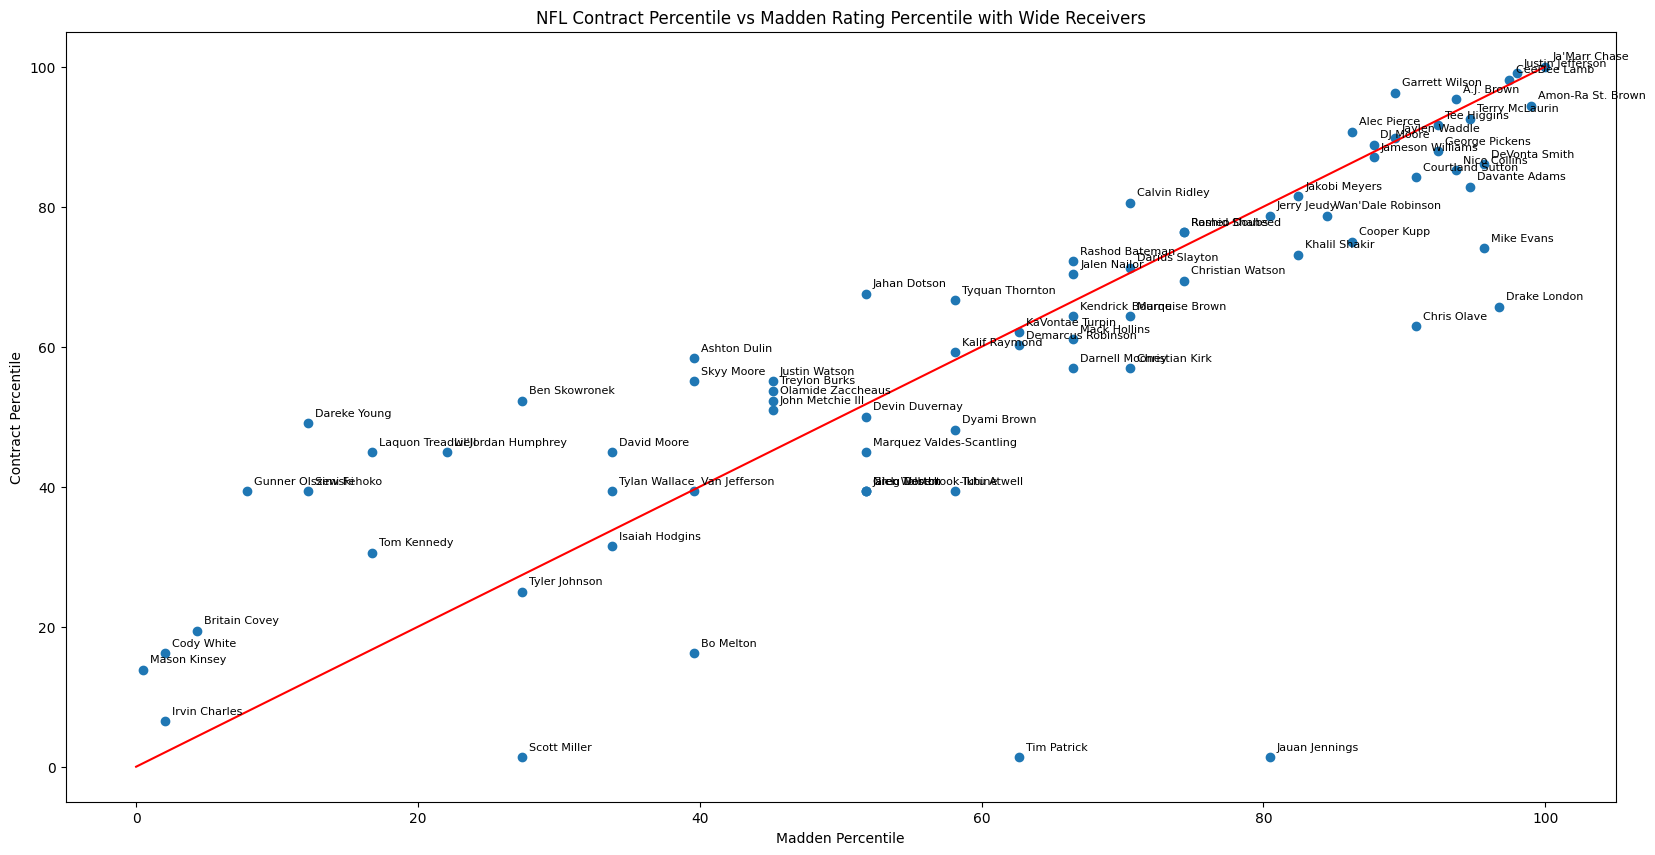

In [30]:
plt.figure(figsize=(20, 10))
plt.scatter(wr_full_cleaned["Madden Percentile"], wr_full_cleaned["Contract Percentile"])

for i, name in enumerate(wr_full_cleaned["Name"]):
    plt.annotate(name,
             (wr_full_cleaned["Madden Percentile"].iloc[i], wr_full_cleaned["Contract Percentile"].iloc[i]),
             textcoords="offset points",
             xytext=(5, 5),
             fontsize=8)
plt.xlabel("Madden Percentile")
plt.ylabel("Contract Percentile")
plt.plot([0, 100], [0, 100], color='red')
plt.title("NFL Contract Percentile vs Madden Rating Percentile with Wide Receivers")
plt.show()

In [31]:
wr_full_cleaned.sort_values("madden_gap", ascending=False)["Name"].to_list()[:10]

['Jauan Jennings',
 'Tim Patrick',
 'Drake London',
 'Chris Olave',
 'Scott Miller',
 'Bo Melton',
 'Mike Evans',
 'Tutu Atwell',
 'Christian Kirk',
 'Nick Westbrook-Ikhine']

In [32]:
wr_full_cleaned.sort_values("madden_gap", ascending=False).tail()

,Name,position,Team,Overall,Player Image,Team Logo,ACCELERATION,AGILITY,JUMPING,STAMINA,STRENGTH,AWARENESS,BCVISION,BLOCKSHEDDING,BREAKSACK,BREAKTACKLE,CARRYING,CATCHINTRAFFIC,CATCHING,CHANGEOFDIRECTION,DEEPROUTERUNNING,FINESSEMOVES,HITPOWER,IMPACTBLOCKING,INJURY,JUKEMOVE,KICKACCURACY,KICKPOWER,KICKRETURN,LEADBLOCK,MANCOVERAGE,MEDIUMROUTERUNNING,OVERALL,PASSBLOCK,PASSBLOCKFINESSE,PASSBLOCKPOWER,PLAYACTION,PLAYRECOGNITION,POWERMOVES,PRESS,PURSUIT,RELEASE,RUNBLOCK,RUNBLOCKFINESSE,RUNBLOCKPOWER,RUNNINGSTYLE,SHORTROUTERUNNING,SPECTACULARCATCH,SPEED,SPINMOVE,STIFFARM,TACKLE,THROWACCURACYDEEP,THROWACCURACYMID,THROWACCURACYSHORT,THROWONTHERUN,THROWPOWER,THROWUNDERPRESSURE,TOUGHNESS,TRUCKING,ZONECOVERAGE,full_name,gsis_id,team,rank,Madden Percentile,Contract Percentile,madden_gap
138,Ben Skowronek,WR,PIT,70,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/4k4tkEjxICBz...,89,80,88,82,68,74,73,41,32,73,73,82,88,78,69,22,51,49,86,72,19,15,55,29,23,73,70,39,27,33,25,23,16,22,52,73,51,25,29,Long Stride Default,74,83,85,66,59,47,10,10,15,10,30,25,83,55,30,Ben Skowronek,00-0036862,PIT,144.0,27.411168,52.314815,-24.903647
176,Simi Fehoko,WR,ARI,67,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/5NdzvrqrP3cl...,89,88,83,81,66,69,76,43,24,70,75,79,81,80,69,10,39,47,90,72,15,22,40,28,27,67,67,37,19,25,28,26,10,23,45,69,45,24,27,Long Stride High and Tight,68,80,90,70,48,43,10,10,15,10,25,18,83,44,38,Simi Fehoko,00-0036646,AZ,174.0,12.182741,39.351852,-27.169111
166,Laquon Treadwell,WR,IND,68,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/5yTvAS7xG5Z8...,86,81,86,83,70,72,80,37,22,72,74,80,83,76,72,11,15,43,88,76,22,23,25,21,16,72,68,43,15,11,20,21,11,16,40,71,45,26,32,Default Stride Loose,74,83,85,69,76,38,18,19,21,23,37,22,83,57,24,Laquon Treadwell,00-0032951,IND,165.0,16.751269,44.907407,-28.156138
181,Gunner Olszewski,WR,NYG,66,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/5hloGwLNaCrg...,89,86,86,83,56,75,78,53,22,67,72,74,80,80,64,33,58,48,88,77,22,20,85,29,58,69,66,33,27,25,20,53,28,54,62,62,47,27,29,Default Stride Loose,70,77,88,71,48,50,20,37,43,42,51,34,94,35,60,Gunner Olszewski,00-0035645,NYG,182.5,7.868020,39.351852,-31.483832
171,Dareke Young,WR,SEA,67,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/2WrGCB8Atuo0...,93,86,88,80,71,66,82,28,19,75,78,79,78,82,66,10,36,45,85,74,17,21,85,27,12,67,67,30,28,29,6,15,10,12,42,62,40,26,31,Long Stride Loose,69,75,91,66,68,30,8,10,15,16,23,11,75,69,10,Dareke Young,00-0037093,LV,174.0,12.182741,49.074074,-36.891333


In [33]:
madden = maddenCopy.copy()

def createDataframe(position='RB'):
    temp = madden.query(f"position == '{position}'")
    temp['rank'] = temp['Overall'].rank(ascending=False)
    N = len(temp)
    temp["percentile"] = 100 - ((temp["rank"] - 1) / (N-1)) * 100
    temp.reset_index(drop=True, inplace=True)
    temp_overall_percentages = temp.copy()

    active_contracts = contracts.query("is_active == True")
    active_nonrookie_contracts_temp = active_contracts.query("draft_year <= 2022").query(f"position == '{position}'")
    active_nonrookie_contracts_temp_short = active_nonrookie_contracts_temp[["gsis_id", "apy"]].copy()
    active_nonrookie_contracts_temp_short["rank"] = active_nonrookie_contracts_temp_short['apy'].rank(ascending=False)
    N = len(active_nonrookie_contracts_temp_short)
    active_nonrookie_contracts_temp_short["percentile"] = 100 - ((active_nonrookie_contracts_temp_short["rank"] - 1) / (N-1)) * 100
    active_nonrookie_contracts_temp_short_cleaned = active_nonrookie_contracts_temp_short[["gsis_id", "percentile"]]

    temp_full = temp_overall_percentages.merge(active_nonrookie_contracts_temp_short_cleaned, on="gsis_id", how="left")
    temp_full_cleaned = temp_full.dropna(subset=["percentile_y"])
    temp_full_cleaned.rename(columns={'percentile_x': 'Madden Percentile', 'percentile_y': 'Contract Percentile'}, inplace=True)
    temp_full_cleaned["madden_gap"] = temp_full_cleaned["Madden Percentile"] - temp_full_cleaned["Contract Percentile"]

    return temp_full_cleaned

temp_full_cleaned = createDataframe()
temp_full_cleaned

/tmp/ipykernel_872/574150249.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['rank'] = temp['Overall'].rank(ascending=False)
/tmp/ipykernel_872/574150249.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp["percentile"] = 100 - ((temp["rank"] - 1) / (N-1)) * 100
/tmp/ipykernel_872/574150249.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html

,Name,position,Team,Overall,Player Image,Team Logo,ACCELERATION,AGILITY,JUMPING,STAMINA,STRENGTH,AWARENESS,BCVISION,BLOCKSHEDDING,BREAKSACK,BREAKTACKLE,CARRYING,CATCHINTRAFFIC,CATCHING,CHANGEOFDIRECTION,DEEPROUTERUNNING,FINESSEMOVES,HITPOWER,IMPACTBLOCKING,INJURY,JUKEMOVE,KICKACCURACY,KICKPOWER,KICKRETURN,LEADBLOCK,MANCOVERAGE,MEDIUMROUTERUNNING,OVERALL,PASSBLOCK,PASSBLOCKFINESSE,PASSBLOCKPOWER,PLAYACTION,PLAYRECOGNITION,POWERMOVES,PRESS,PURSUIT,RELEASE,RUNBLOCK,RUNBLOCKFINESSE,RUNBLOCKPOWER,RUNNINGSTYLE,SHORTROUTERUNNING,SPECTACULARCATCH,SPEED,SPINMOVE,STIFFARM,TACKLE,THROWACCURACYDEEP,THROWACCURACYMID,THROWACCURACYSHORT,THROWONTHERUN,THROWPOWER,THROWUNDERPRESSURE,TOUGHNESS,TRUCKING,ZONECOVERAGE,full_name,gsis_id,team,rank,Madden Percentile,Contract Percentile,madden_gap
1,Christian McCaffrey,RB,SF,96,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/1SoIzWJtk28y...,93,94,90,93,74,99,95,32,38,93,95,72,83,93,69,10,27,45,83,90,23,29,88,47,12,78,96,60,32,36,31,27,10,15,44,76,38,22,22,NaN,82,75,90,83,80,36,33,41,45,47,52,37,94,67,17,Christian McCaffrey,00-0033280,SF,2.5,98.770492,98.148148,0.622344
2,Jonathan Taylor,RB,IND,96,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/5yTvAS7xG5Z8...,94,86,84,96,82,96,96,25,28,96,97,55,71,86,49,10,25,37,90,93,15,17,45,32,12,56,96,58,24,29,14,13,10,14,33,51,34,24,27,Default,64,59,94,81,94,27,15,20,25,17,29,15,92,88,19,Jonathan Taylor,00-0036223,IND,2.5,98.770492,90.740741,8.029751
4,Derrick Henry,RB,BAL,94,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/3zZnTQ4izXUr...,87,83,88,92,87,95,97,36,29,92,89,47,66,78,41,12,33,47,96,84,20,21,36,49,14,49,94,66,38,43,15,20,11,16,41,47,42,31,35,NaN,56,55,93,74,99,44,23,29,40,32,42,26,97,92,19,Derrick Henry,00-0032764,BAL,5.0,96.721311,96.296296,0.425015
5,Saquon Barkley,RB,PHI,92,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/1Nt5pFCpjcBc...,94,93,96,94,81,87,87,24,31,84,96,62,74,92,65,25,17,37,91,89,14,19,81,34,15,67,92,60,33,38,18,21,17,10,36,69,36,31,35,Default,75,73,95,86,88,28,29,34,41,36,41,18,90,84,13,Saquon Barkley,00-0034844,PHI,6.0,95.901639,100.000000,-4.098361
6,Josh Jacobs,RB,GB,91,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/4ztQk5Xogdkr...,90,86,84,92,83,89,93,28,39,94,94,53,72,83,41,10,25,54,93,91,10,15,77,38,22,55,91,56,36,40,19,20,10,20,36,51,39,27,33,Default,62,55,90,80,91,34,23,31,37,27,36,19,95,90,30,Josh Jacobs,00-0035700,GB,7.0,95.081967,86.111111,8.970856
7,Kenneth Walker III,RB,SEA,90,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/2WrGCB8Atuo0...,94,92,83,90,81,87,89,33,28,92,96,46,67,90,41,10,32,35,84,87,12,15,73,31,12,47,90,54,30,34,22,15,10,15,38,48,33,30,23,Short Stride Default,54,45,94,76,84,36,11,15,20,18,27,11,92,88,18,Kenneth Walker III,00-0038134,KC,8.0,94.262295,94.444444,-0.182149
8,Kyren Williams,RB,LA,89,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/wS8JnLBEBj9e...,90,83,78,89,79,97,88,36,28,91,91,63,72,85,55,10,36,47,86,88,15,19,79,45,22,63,89,59,41,37,26,27,10,22,45,60,47,38,32,Default,69,63,87,77,90,42,27,33,38,34,44,29,85,93,30,Kyren Williams,00-0037840,LA,9.0,93.442623,81.481481,11.961141
11,Breece Hall,RB,NYJ,86,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/7M46e9acznPL...,92,90,92,90,76,86,85,29,31,85,86,59,70,91,51,10,24,44,89,91,15,18,42,45,13,60,86,56,33,37,19,17,10,16,33,58,43,35,32,Default,69,59,93,85,80,29,12,15,20,24,32,19,90,80,17,Breece Hall,00-0038120,NYJ,12.5,90.573770,92.592593,-2.018822
13,D'Andre Swift,RB,CHI,85,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/6jaEsYrn1V45...,91,89,93,89,68,92,87,28,23,83,91,61,71,88,61,16,30,41,87,87,12,18,63,33,16,66,85,56,35,32,17,17,22,16,36,59,32,19,23,Short Stride Default,73,59,90,80,77,31,15,25,30,28,38,19,85,75,13,D'Andre Swift,00

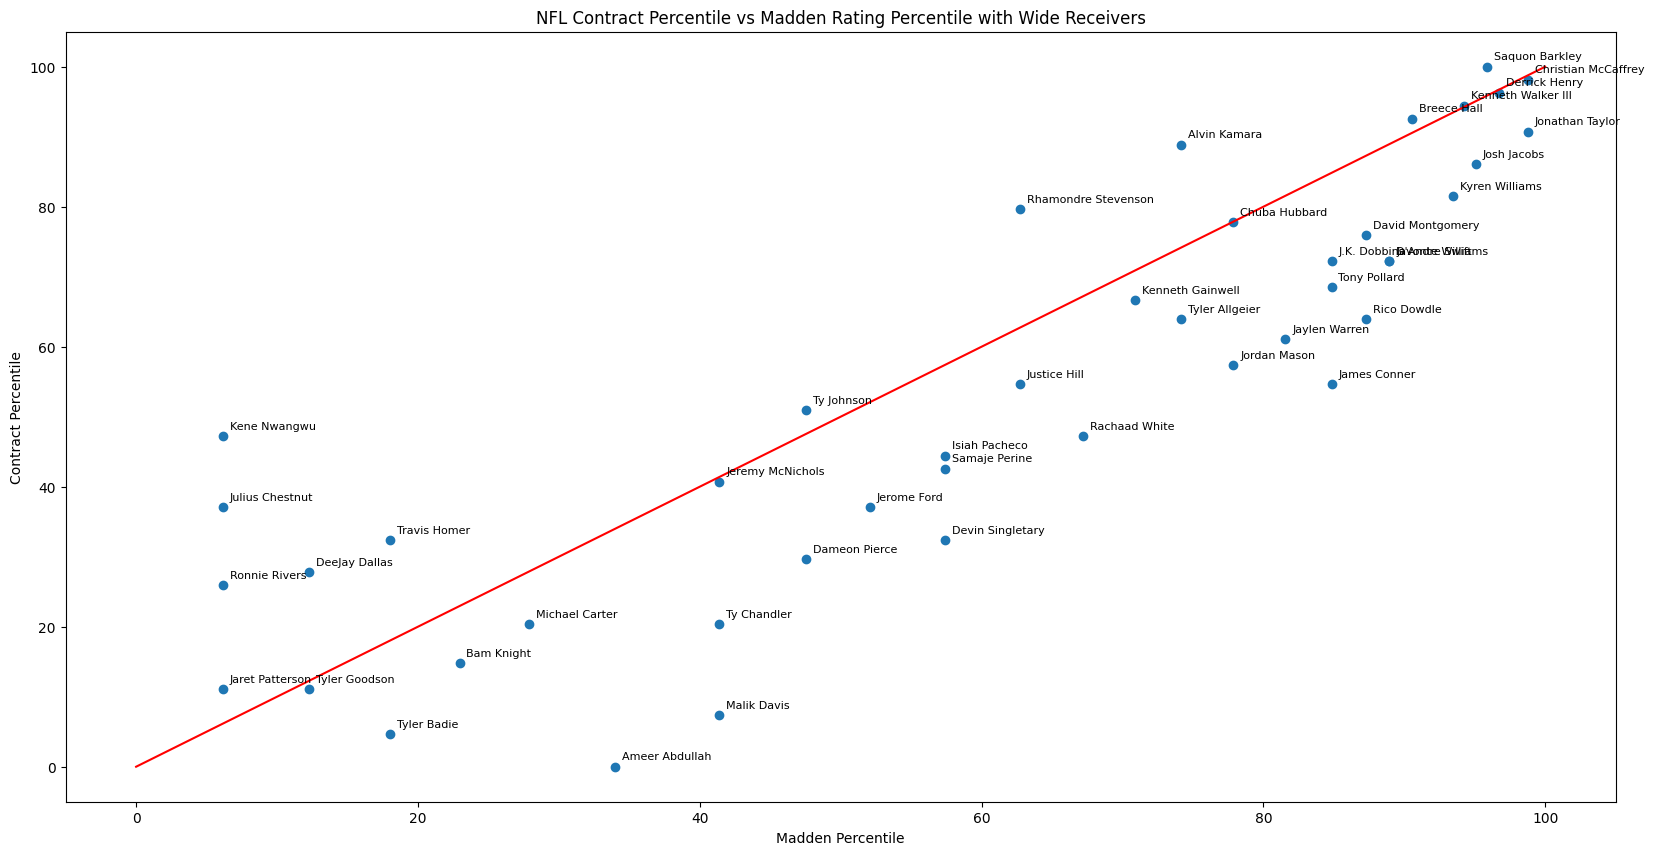

In [34]:
plt.figure(figsize=(20, 10))
plt.scatter(temp_full_cleaned["Madden Percentile"], temp_full_cleaned["Contract Percentile"])

for i, name in enumerate(temp_full_cleaned["Name"]):
    plt.annotate(name,
             (temp_full_cleaned["Madden Percentile"].iloc[i], temp_full_cleaned["Contract Percentile"].iloc[i]),
             textcoords="offset points",
             xytext=(5, 5),
             fontsize=8)
plt.xlabel("Madden Percentile")
plt.ylabel("Contract Percentile")
plt.plot([0, 100], [0, 100], color='red')
plt.title("NFL Contract Percentile vs Madden Rating Percentile with Wide Receivers")
plt.show()

/tmp/ipykernel_872/574150249.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['rank'] = temp['Overall'].rank(ascending=False)
/tmp/ipykernel_872/574150249.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp["percentile"] = 100 - ((temp["rank"] - 1) / (N-1)) * 100
/tmp/ipykernel_872/574150249.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html

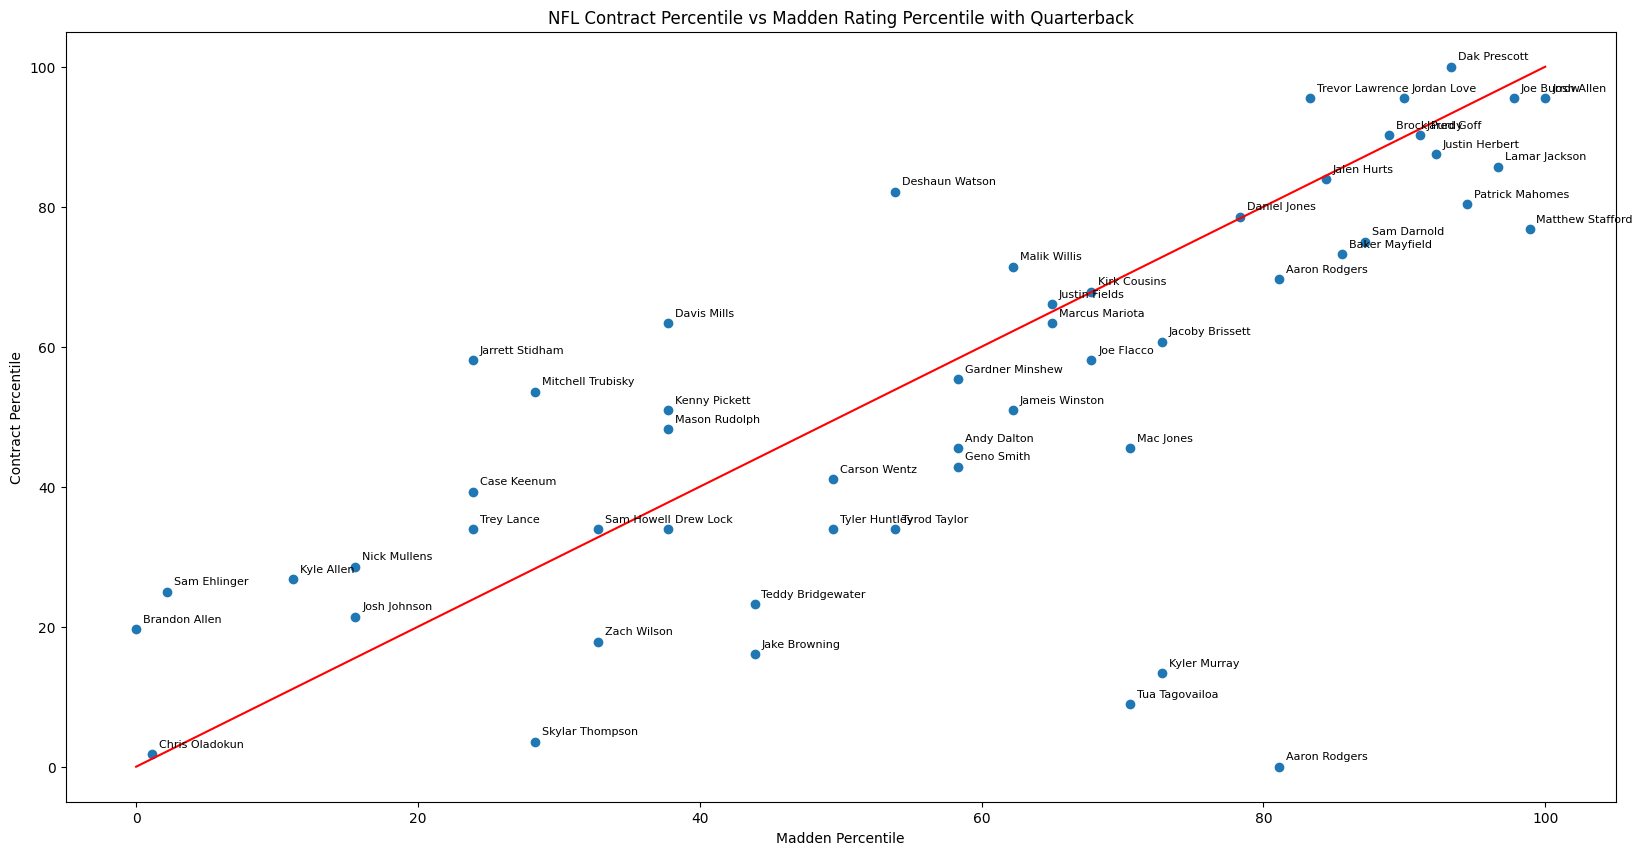

In [35]:


def plotContractVsOverall(dataframe, position):
    plt.figure(figsize=(20, 10))
    plt.scatter(temp_full_cleaned["Madden Percentile"], temp_full_cleaned["Contract Percentile"])

    for i, name in enumerate(temp_full_cleaned["Name"]):
        plt.annotate(name,
                (temp_full_cleaned["Madden Percentile"].iloc[i], temp_full_cleaned["Contract Percentile"].iloc[i]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=8)
    plt.xlabel("Madden Percentile")
    plt.ylabel("Contract Percentile")
    plt.plot([0, 100], [0, 100], color='red')
    plt.title(f"NFL Contract Percentile vs Madden Rating Percentile with {position}")
    plt.show()

temp_full_cleaned = createDataframe('QB')
plotContractVsOverall(temp_full_cleaned, "Quarterback")


/tmp/ipykernel_872/574150249.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['rank'] = temp['Overall'].rank(ascending=False)
/tmp/ipykernel_872/574150249.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp["percentile"] = 100 - ((temp["rank"] - 1) / (N-1)) * 100
/tmp/ipykernel_872/574150249.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html

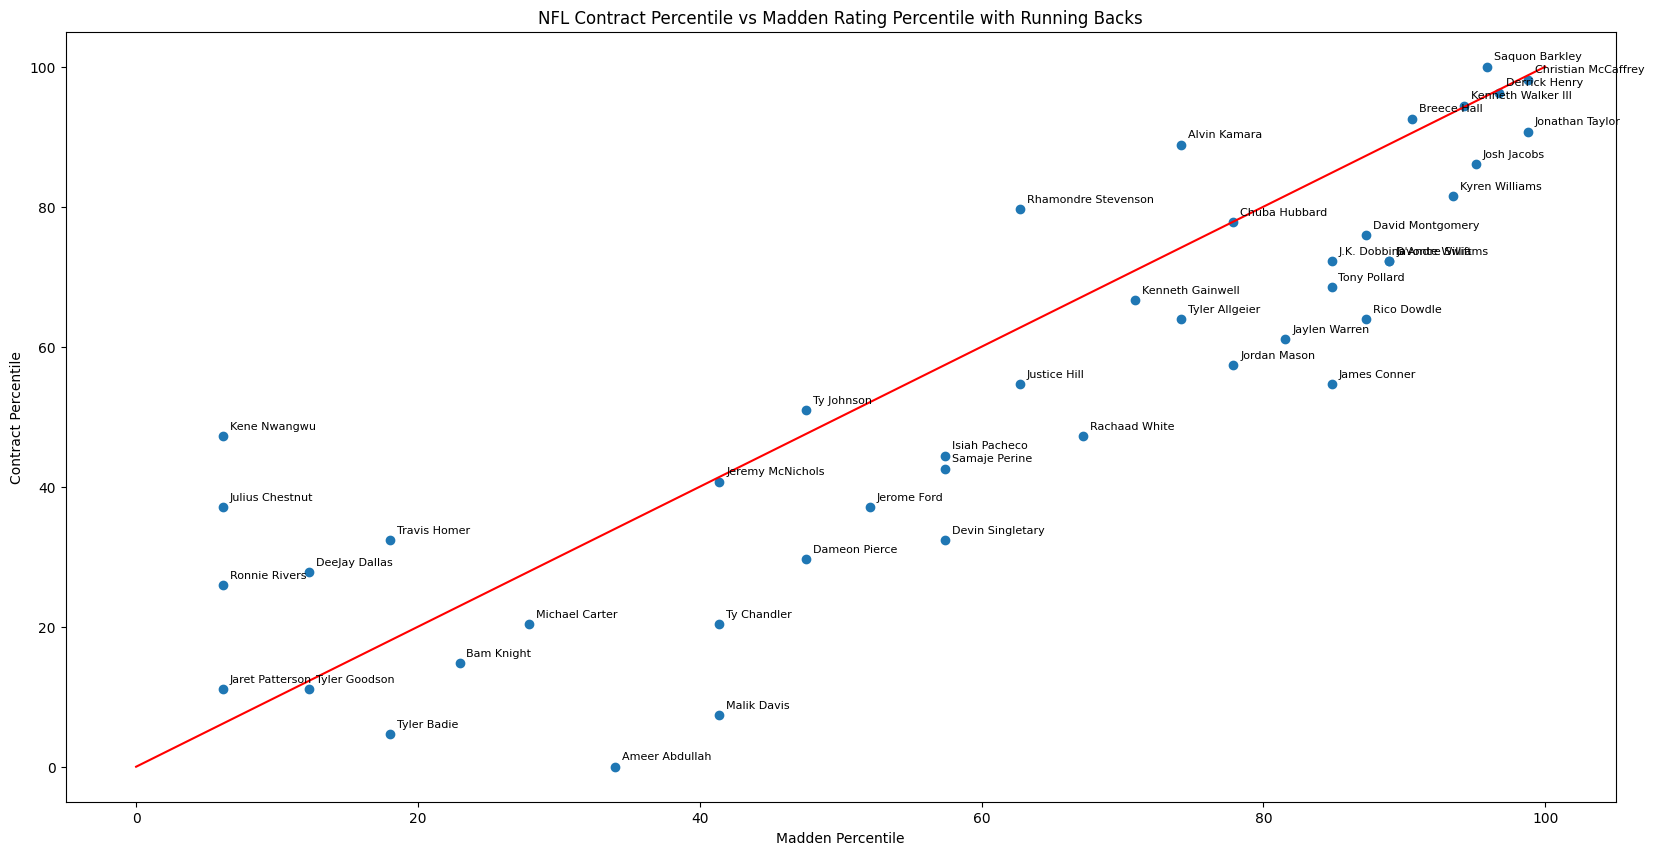

In [36]:
temp_full_cleaned = createDataframe('RB')
plotContractVsOverall(temp_full_cleaned, "Running Backs")

/tmp/ipykernel_872/574150249.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['rank'] = temp['Overall'].rank(ascending=False)
/tmp/ipykernel_872/574150249.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp["percentile"] = 100 - ((temp["rank"] - 1) / (N-1)) * 100
/tmp/ipykernel_872/574150249.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html

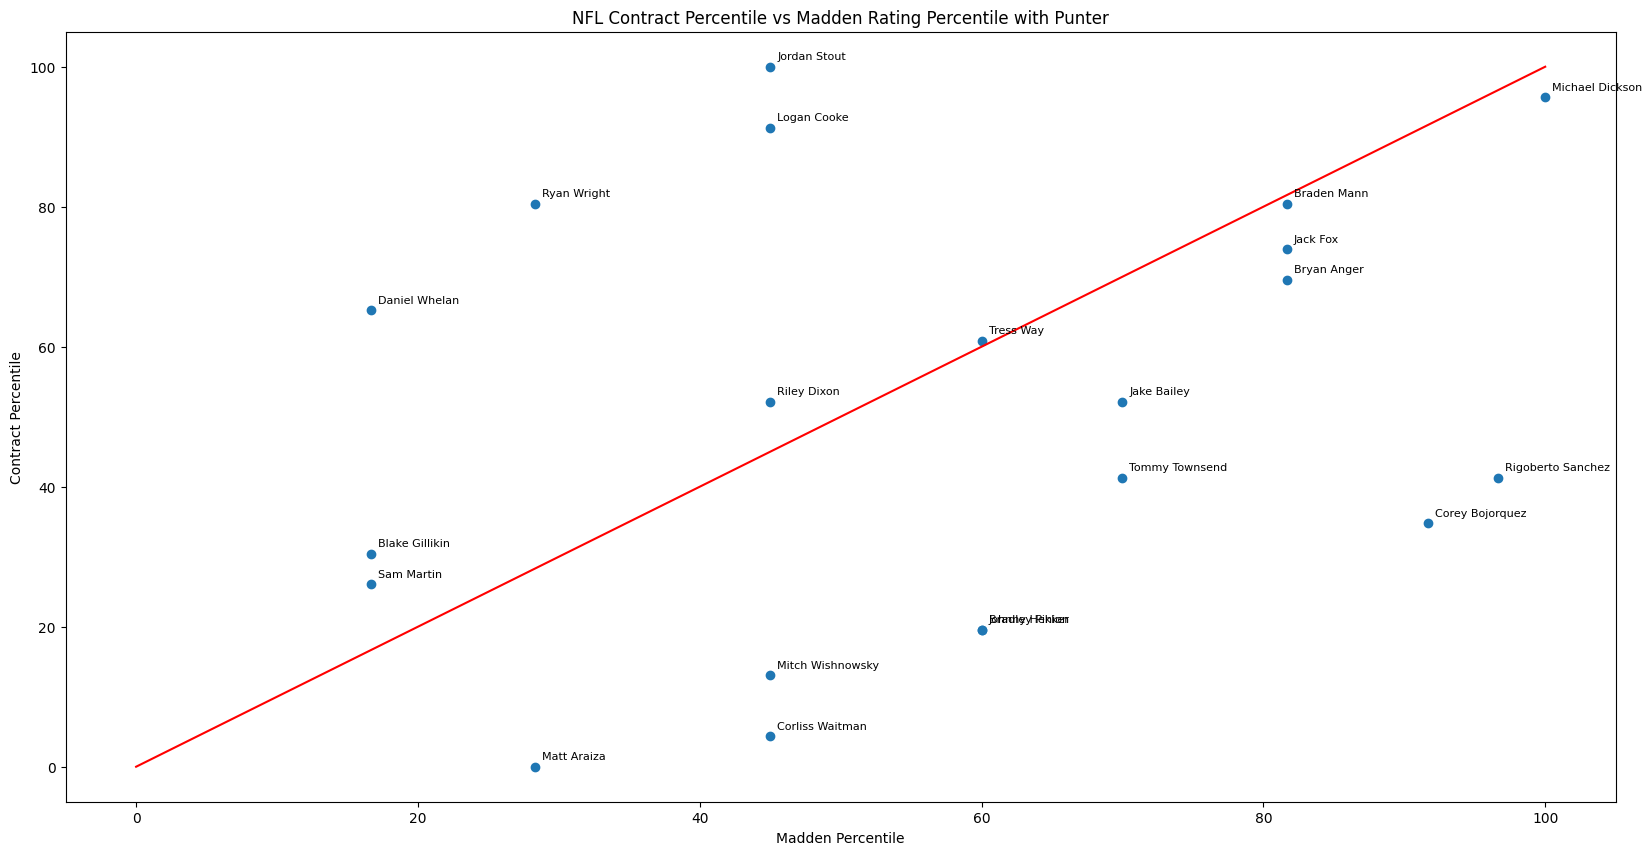

In [37]:
temp_full_cleaned = createDataframe('P')
plotContractVsOverall(temp_full_cleaned, "Punter")

## Contract Size Per Position Groups

In [42]:
active_contracts = contracts.query("is_active == True & draft_year <= 2022")

active_contracts.groupby("position").agg({"apy": "mean"})

##Do this but for top 25 players in that position based on madden rankings

,apy
position,
C,6.437446
CB,7.207708
ED,10.732979
FB,2.952917
IDL,8.496983
K,3.776592
LB,5.916228
LG,7.813925
LS,1.415633


In [45]:
positions = madden["position"].unique()

top15_list = []

for pos in positions:
    temp = madden[madden["position"] == pos].copy()
    temp["rank"] = temp["Overall"].rank(ascending=False)
    top15 = temp.nsmallest(15, "rank")[["Name", "gsis_id", "position", "Overall", "rank"]]
    top15_list.append(top15)

top15_all = pd.concat(top15_list, ignore_index=True)

# Merge with active contracts
active_contracts = contracts[contracts["is_active"] == True]
top15_merged = top15_all.merge(active_contracts[["gsis_id", "apy", "position"]], on="gsis_id", how="left")

# Average APY by position
avg_apy_by_position = top15_merged.groupby("position_x")["apy"].mean().reset_index()
avg_apy_by_position.columns = ["position", "avg_apy_top15"]
avg_apy_by_position = avg_apy_by_position.sort_values("avg_apy_top15", ascending=False)
avg_apy_by_position.reset_index(drop=True, inplace=True)
avg_apy_by_position

,position,avg_apy_top15
0,QB,43.824319
1,DE,29.644461
2,WR,25.823002
3,OT,22.999138
4,DT,19.453294
5,G,17.705256
6,CB,14.855009
7,FS,11.748461
8,MLB,11.260047
9,S,10.764383


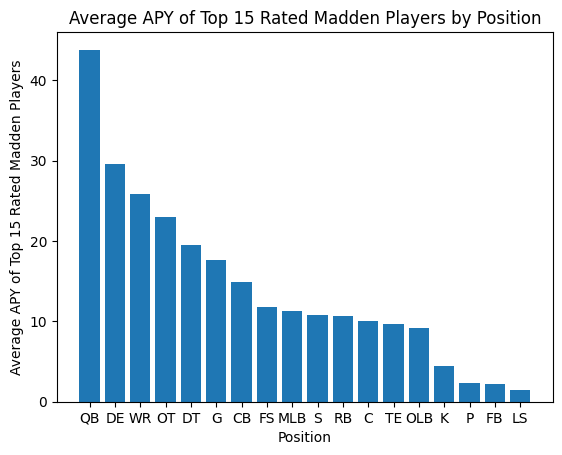

In [49]:
plt.bar(avg_apy_by_position["position"], avg_apy_by_position["avg_apy_top15"])
plt.xlabel("Position")
plt.ylabel("Average APY of Top 15 Rated Madden Players")
plt.title("Average APY of Top 15 Rated Madden Players by Position")
plt.show()

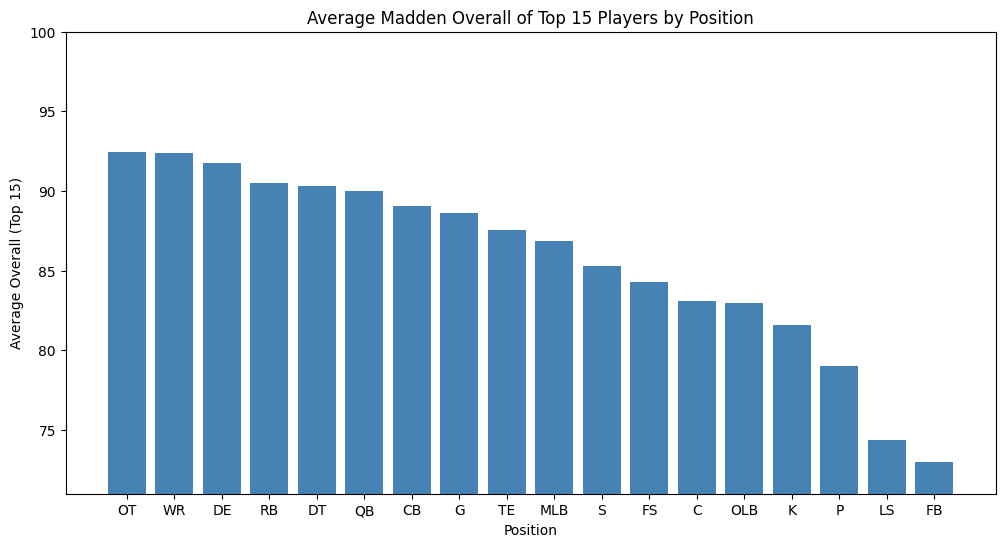

In [50]:
avg_overall_by_position = top15_all.groupby("position")["Overall"].mean().reset_index()
avg_overall_by_position.columns = ["position", "avg_overall"]
avg_overall_by_position = avg_overall_by_position.sort_values("avg_overall", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(avg_overall_by_position["position"], avg_overall_by_position["avg_overall"], color='steelblue')
plt.xlabel("Position")
plt.ylabel("Average Overall (Top 15)")
plt.title("Average Madden Overall of Top 15 Players by Position")
plt.ylim(avg_overall_by_position["avg_overall"].min() - 2, 100)
plt.show()

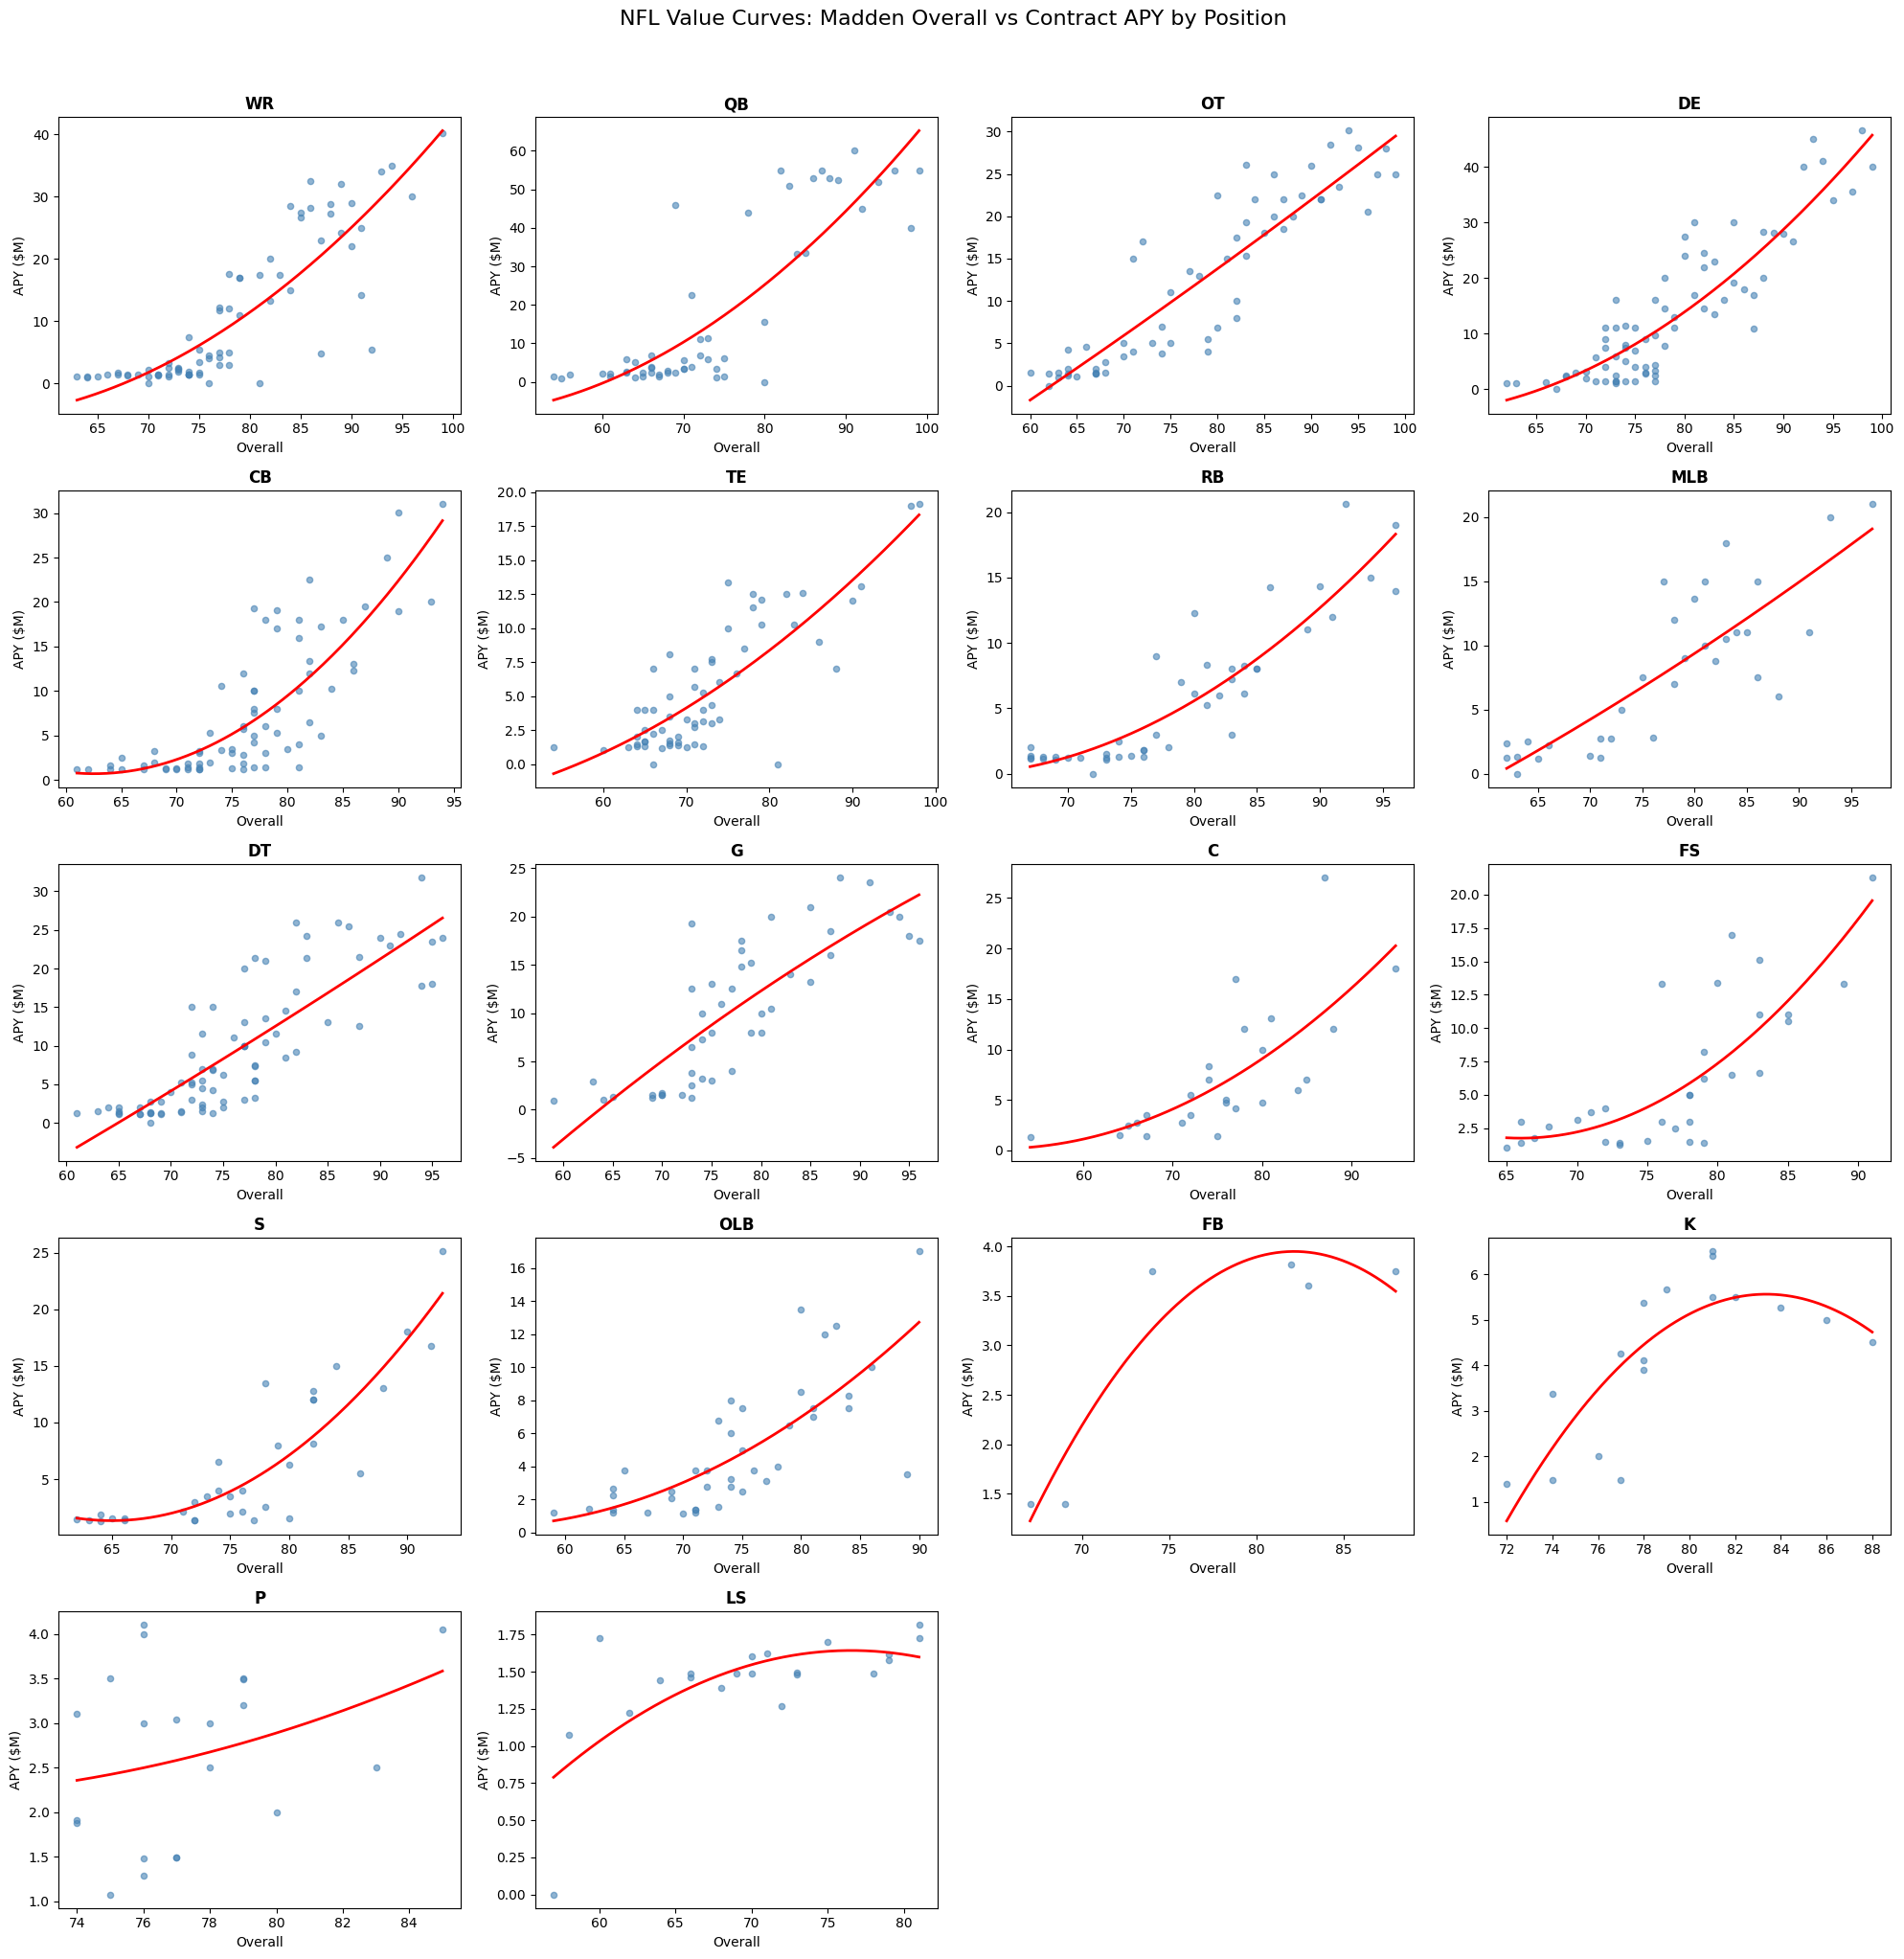

In [54]:
def normalize_position(pos):
    mapping = {
        'DE': 'ED',
        'DT': 'IDL',
        'MLB': 'LB',
        'OLB': 'LB',
        'FS': 'S',
        'G': ['LG', 'RG'],
        'OT': ['LT', 'RT'],
    }
    return mapping.get(pos, pos)

positions = madden["position"].unique()
n_positions = len(positions)
n_cols = 4
n_rows = int(np.ceil(n_positions / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

active_nonrookie = contracts[(contracts["is_active"] == True) & (contracts["draft_year"] <= 2022)]

for i, pos in enumerate(positions):
    ax = axes[i]

    madden_pos = madden[madden["position"] == pos][["Name", "gsis_id", "Overall"]]

    # Use normalized position for contract lookup
    contract_positions = normalize_position(pos)
    if isinstance(contract_positions, list):
        contracts_pos = active_nonrookie[active_nonrookie["position"].isin(contract_positions)][["gsis_id", "apy"]]
    else:
        contracts_pos = active_nonrookie[active_nonrookie["position"] == contract_positions][["gsis_id", "apy"]]

    merged = madden_pos.merge(contracts_pos, on="gsis_id", how="inner").dropna(subset=["apy", "Overall"])

    if len(merged) < 3:
        ax.set_title(f"{pos} (insufficient data)")
        ax.axis("off")
        continue

    x = merged["Overall"].values
    y = merged["apy"].values

    coeffs = np.polyfit(x, y, deg=2)
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = np.polyval(coeffs, x_line)

    ax.scatter(x, y, alpha=0.6, s=20, color="steelblue")
    ax.plot(x_line, y_line, color="red", linewidth=2)
    ax.set_title(pos, fontsize=12, fontweight="bold")
    ax.set_xlabel("Overall")
    ax.set_ylabel("APY ($M)")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("NFL Value Curves: Madden Overall vs Contract APY by Position", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

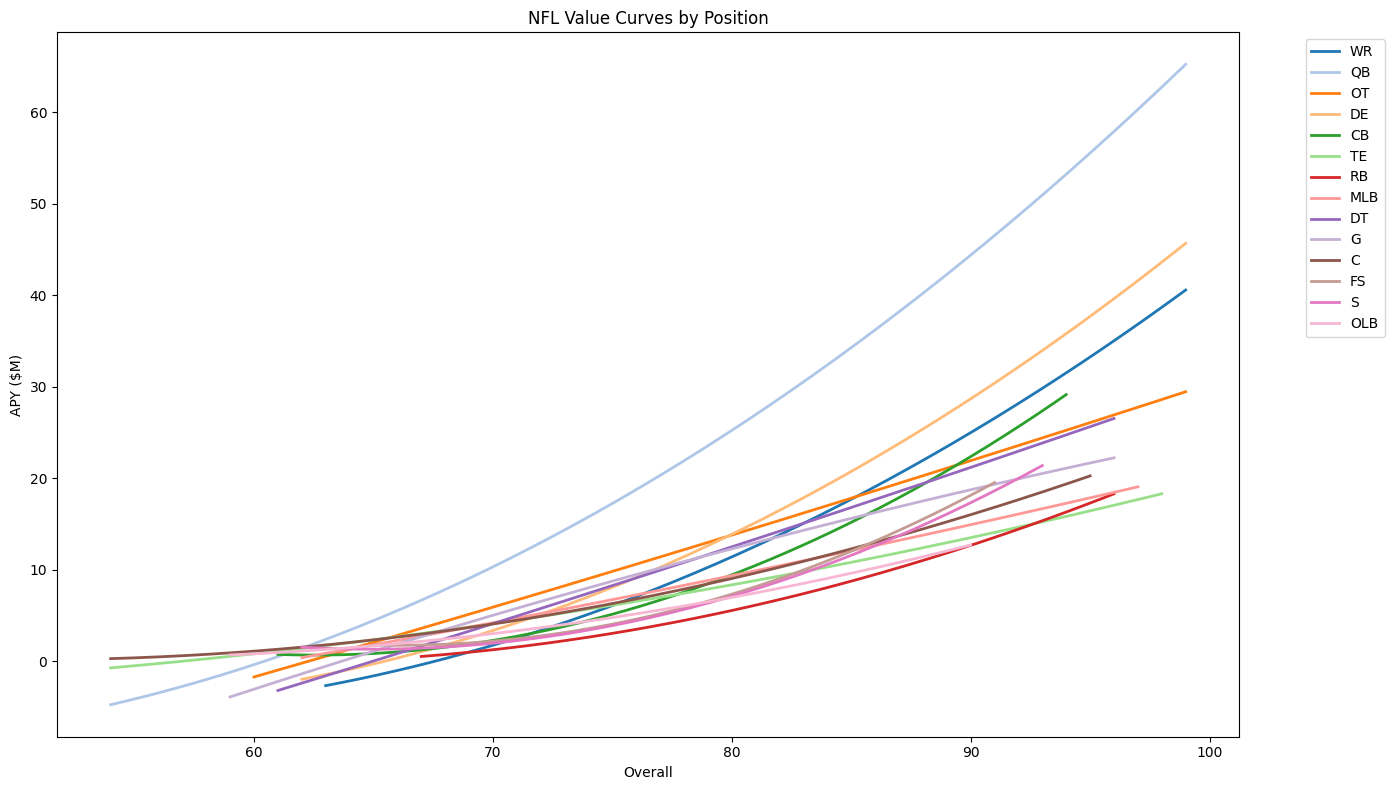

In [55]:
def normalize_position(pos):
    mapping = {
        'DE': 'ED',
        'DT': 'IDL',
        'MLB': 'LB',
        'OLB': 'LB',
        'FS': 'S',
        'G': ['LG', 'RG'],
        'OT': ['LT', 'RT'],
    }
    return mapping.get(pos, pos)

exclude = ['FB', 'K', 'P', 'LS']
positions = [p for p in madden["position"].unique() if p not in exclude]

active_nonrookie = contracts[(contracts["is_active"] == True) & (contracts["draft_year"] <= 2022)]

plt.figure(figsize=(14, 8))
colors = plt.cm.tab20.colors

for i, pos in enumerate(positions):
    madden_pos = madden[madden["position"] == pos][["Name", "gsis_id", "Overall"]]

    contract_positions = normalize_position(pos)
    if isinstance(contract_positions, list):
        contracts_pos = active_nonrookie[active_nonrookie["position"].isin(contract_positions)][["gsis_id", "apy"]]
    else:
        contracts_pos = active_nonrookie[active_nonrookie["position"] == contract_positions][["gsis_id", "apy"]]

    merged = madden_pos.merge(contracts_pos, on="gsis_id", how="inner").dropna(subset=["apy", "Overall"])

    if len(merged) < 3:
        continue

    x = merged["Overall"].values
    y = merged["apy"].values

    coeffs = np.polyfit(x, y, deg=2)
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = np.polyval(coeffs, x_line)

    color = colors[i % len(colors)]
    plt.plot(x_line, y_line, color=color, linewidth=2, label=pos)

plt.xlabel("Overall")
plt.ylabel("APY ($M)")
plt.title("NFL Value Curves by Position")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

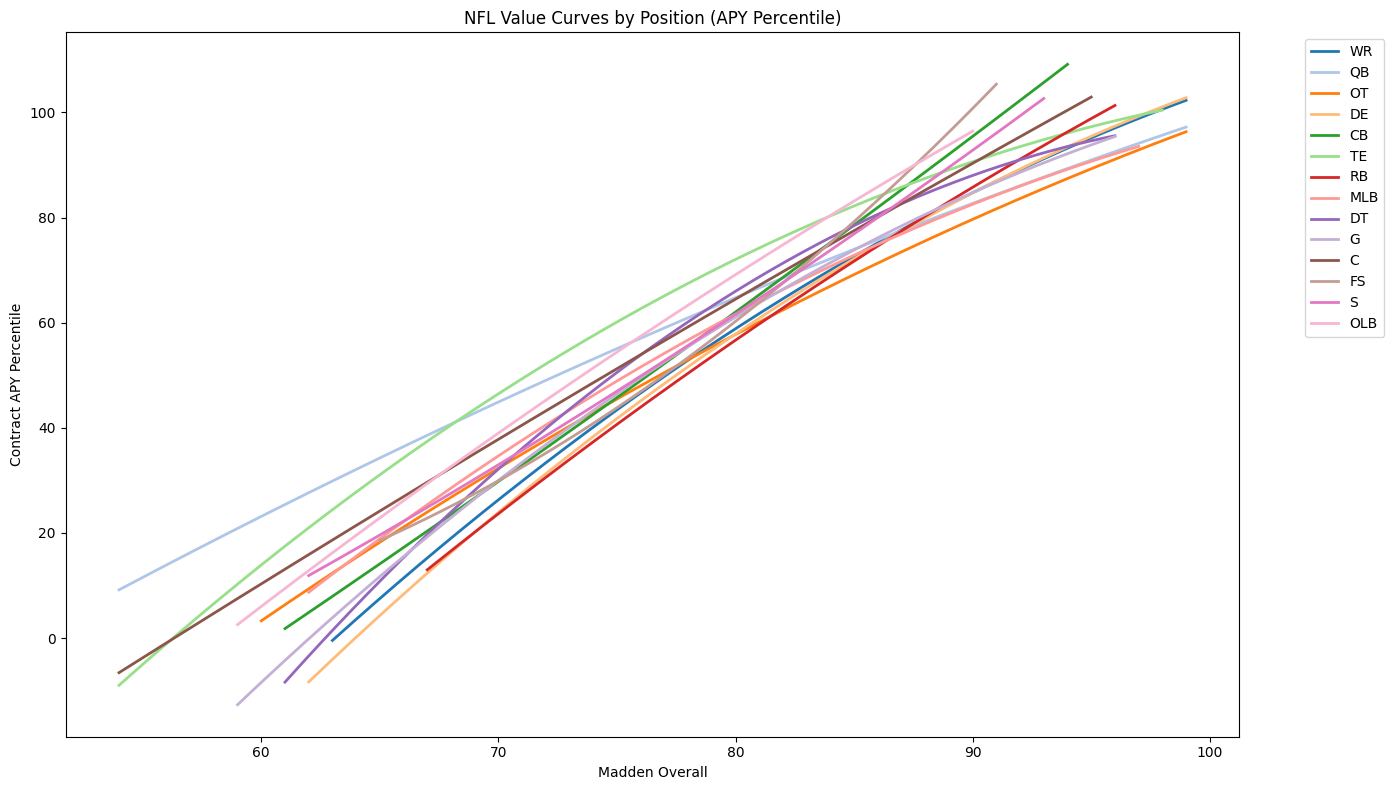

In [57]:
def normalize_position(pos):
    mapping = {
        'DE': 'ED',
        'DT': 'IDL',
        'MLB': 'LB',
        'OLB': 'LB',
        'FS': 'S',
        'G': ['LG', 'RG'],
        'OT': ['LT', 'RT'],
    }
    return mapping.get(pos, pos)

exclude = ['FB', 'K', 'P', 'LS']
positions = [p for p in madden["position"].unique() if p not in exclude]

active_nonrookie = contracts[(contracts["is_active"] == True) & (contracts["draft_year"] <= 2022)]

plt.figure(figsize=(14, 8))
colors = plt.cm.tab20.colors

for i, pos in enumerate(positions):
    madden_pos = madden[madden["position"] == pos][["Name", "gsis_id", "Overall"]]

    contract_positions = normalize_position(pos)
    if isinstance(contract_positions, list):
        contracts_pos = active_nonrookie[active_nonrookie["position"].isin(contract_positions)][["gsis_id", "apy"]]
    else:
        contracts_pos = active_nonrookie[active_nonrookie["position"] == contract_positions][["gsis_id", "apy"]]

    merged = madden_pos.merge(contracts_pos, on="gsis_id", how="inner").dropna(subset=["apy", "Overall"])

    if len(merged) < 3:
        continue

    merged = merged.copy()
    N = len(merged)
    merged["apy_percentile"] = merged["apy"].rank(ascending=True) / N * 100

    x = merged["Overall"].values
    y = merged["apy_percentile"].values

    coeffs = np.polyfit(x, y, deg=2)
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = np.polyval(coeffs, x_line)

    color = colors[i % len(colors)]
    plt.plot(x_line, y_line, color=color, linewidth=2, label=pos)

plt.xlabel("Madden Overall")
plt.ylabel("Contract APY Percentile")
plt.title("NFL Value Curves by Position (APY Percentile)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

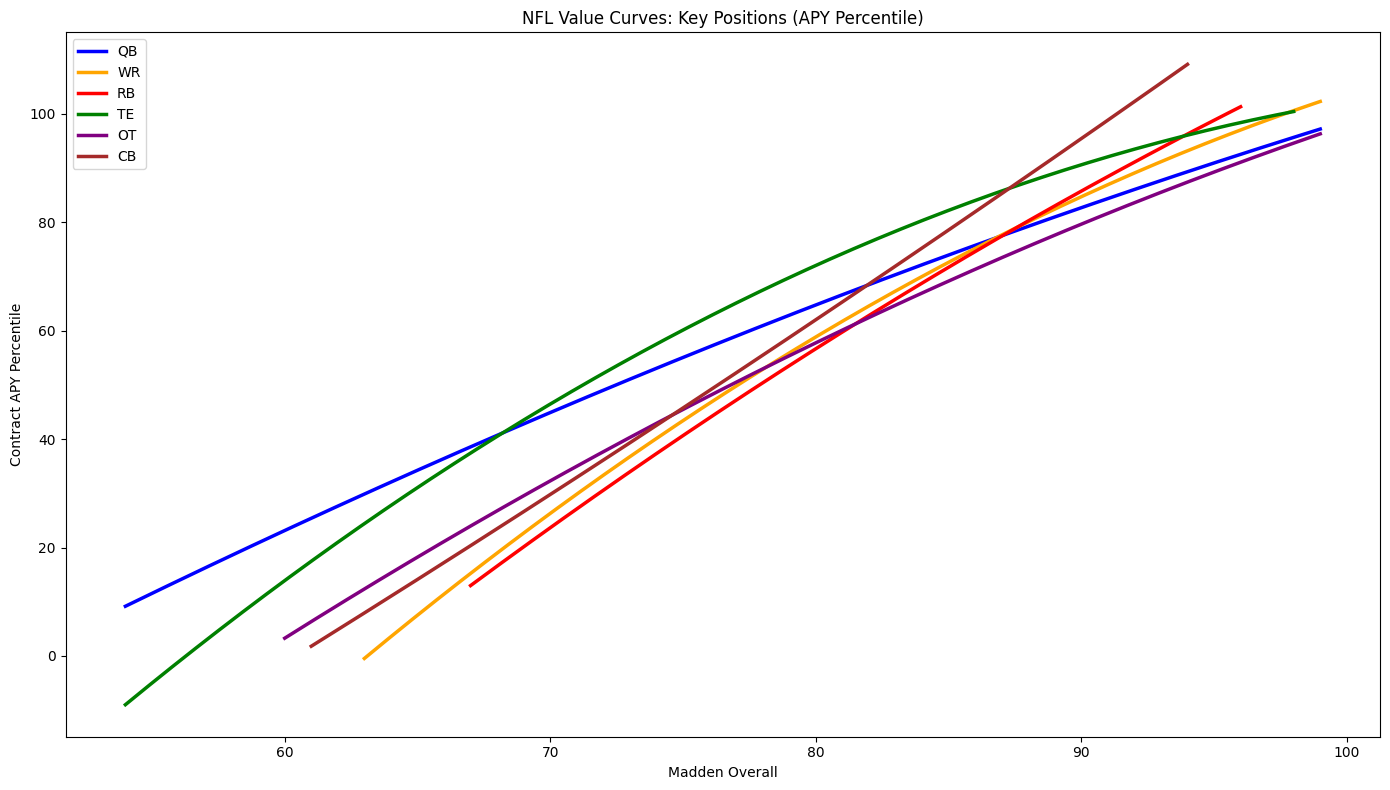

In [60]:
# Plot 1: Key positions only (most meaningful)
key_positions = ['QB', 'WR', 'RB', 'TE', 'OT', 'CB']

plt.figure(figsize=(14, 8))
colors_key = {'QB': 'blue', 'WR': 'orange', 'RB': 'red', 'TE': 'green', 'OT': 'purple', 'CB': 'brown'}

for pos in key_positions:
    madden_pos = madden[madden["position"] == pos][["Name", "gsis_id", "Overall"]]
    contract_positions = normalize_position(pos)
    if isinstance(contract_positions, list):
        contracts_pos = active_nonrookie[active_nonrookie["position"].isin(contract_positions)][["gsis_id", "apy"]]
    else:
        contracts_pos = active_nonrookie[active_nonrookie["position"] == contract_positions][["gsis_id", "apy"]]
    merged = madden_pos.merge(contracts_pos, on="gsis_id", how="inner").dropna(subset=["apy", "Overall"]).copy()

    if len(merged) < 3:
        continue

    N = len(merged)
    merged["apy_percentile"] = merged["apy"].rank(ascending=True) / N * 100
    x, y = merged["Overall"].values, merged["apy_percentile"].values
    coeffs = np.polyfit(x, y, deg=2)
    x_line = np.linspace(x.min(), x.max(), 200)
    plt.plot(x_line, np.polyval(coeffs, x_line), color=colors_key[pos], linewidth=2.5, label=pos)

plt.xlabel("Madden Overall")
plt.ylabel("Contract APY Percentile")
plt.title("NFL Value Curves: Key Positions (APY Percentile)")
plt.legend()
plt.tight_layout()
plt.show()

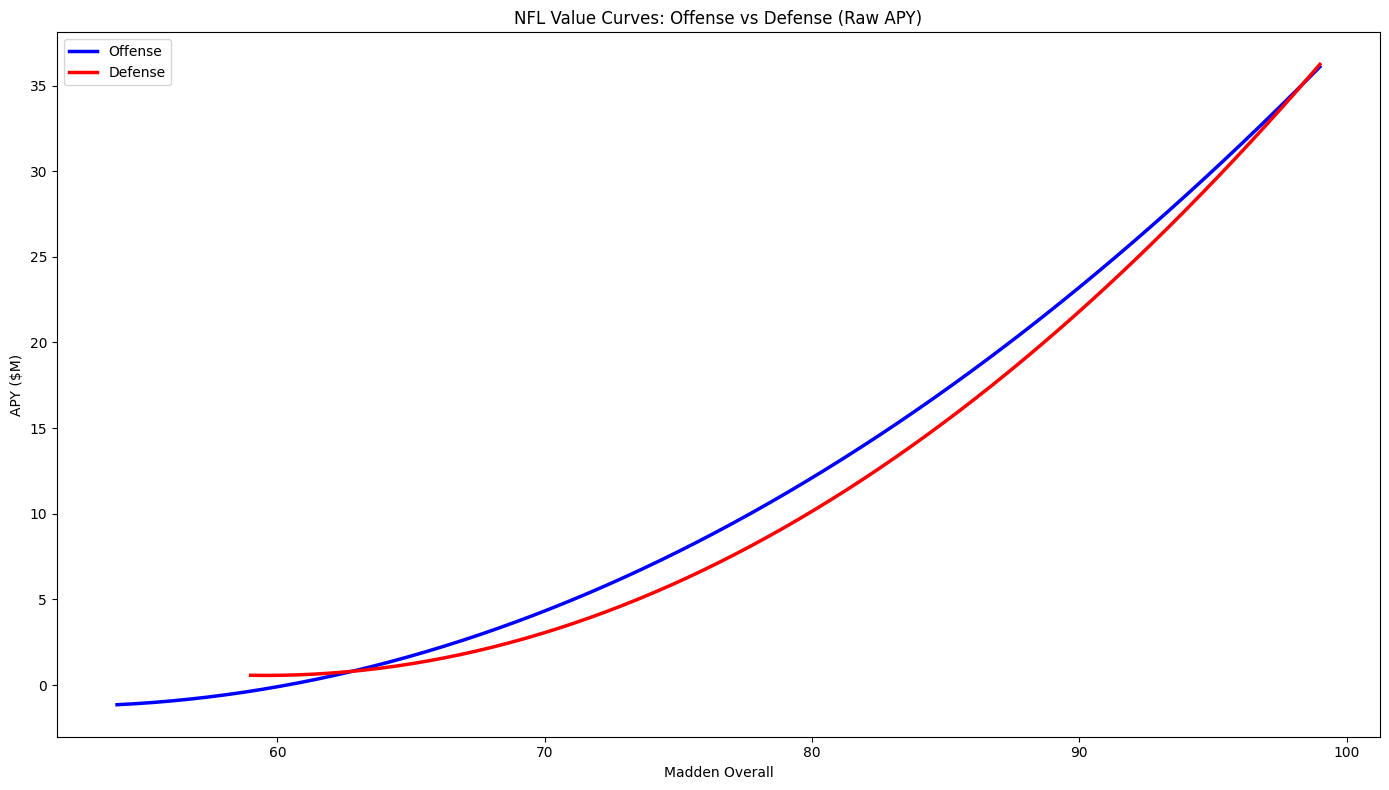

In [62]:
offense = ['QB', 'WR', 'RB', 'TE', 'OT', 'G']
defense = ['DE', 'DT', 'CB', 'S', 'MLB', 'OLB', 'FS']

def get_merged(positions):
    dfs = []
    for pos in positions:
        madden_pos = madden[madden["position"] == pos][["Name", "gsis_id", "Overall"]]
        contract_positions = normalize_position(pos)
        if isinstance(contract_positions, list):
            contracts_pos = active_nonrookie[active_nonrookie["position"].isin(contract_positions)][["gsis_id", "apy"]]
        else:
            contracts_pos = active_nonrookie[active_nonrookie["position"] == contract_positions][["gsis_id", "apy"]]
        merged = madden_pos.merge(contracts_pos, on="gsis_id", how="inner").dropna(subset=["apy", "Overall"])
        dfs.append(merged)
    return pd.concat(dfs, ignore_index=True)

offense_df = get_merged(offense)
defense_df = get_merged(defense)

plt.figure(figsize=(14, 8))

for df, color, label in [(offense_df, 'blue', 'Offense'), (defense_df, 'red', 'Defense')]:
    x, y = df["Overall"].values, df["apy"].values
    coeffs = np.polyfit(x, y, deg=2)
    x_line = np.linspace(x.min(), x.max(), 200)
    plt.plot(x_line, np.polyval(coeffs, x_line), color=color, linewidth=2.5, label=label)

plt.xlabel("Madden Overall")
plt.ylabel("APY ($M)")
plt.title("NFL Value Curves: Offense vs Defense (Raw APY)")
plt.legend()
plt.tight_layout()
plt.show()

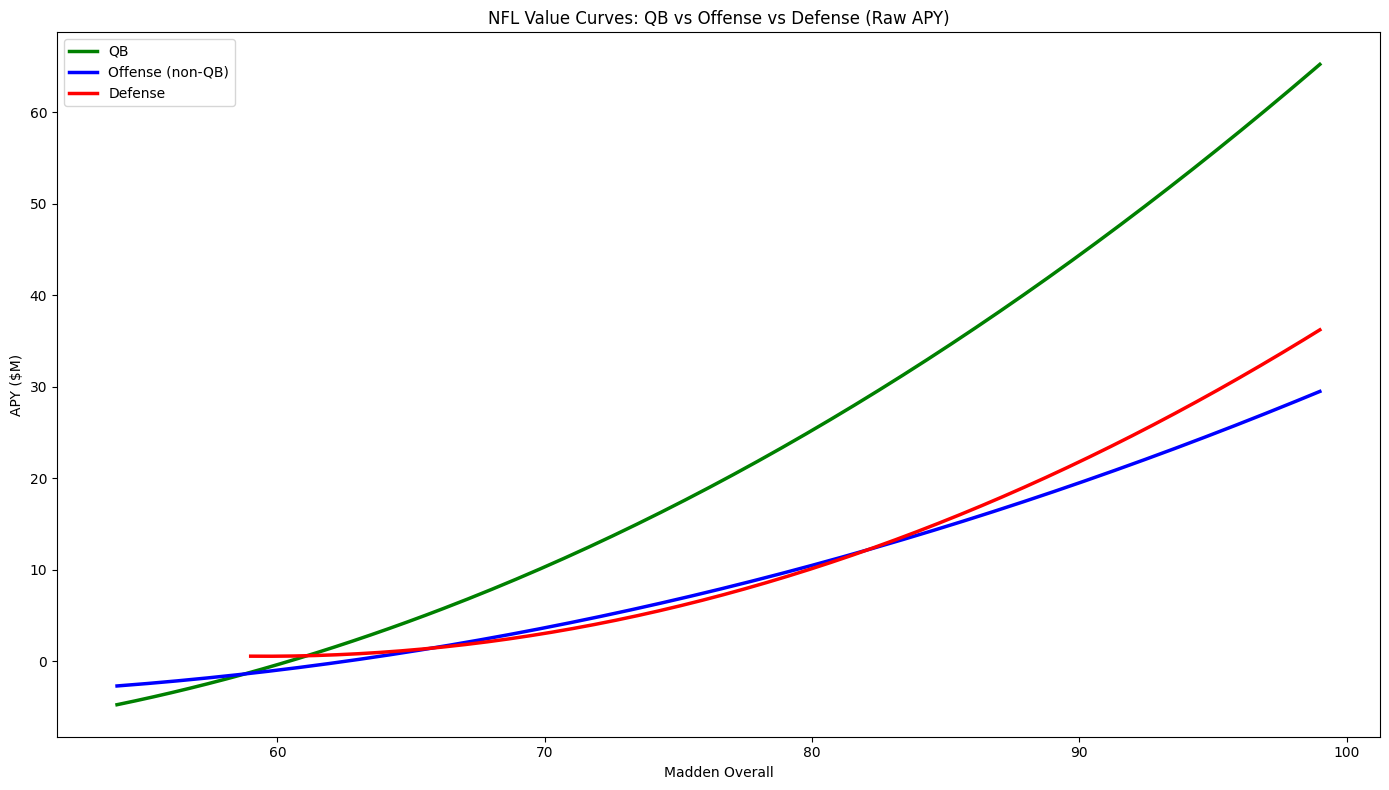

In [63]:
qb = ['QB']
offense = ['WR', 'RB', 'TE', 'OT', 'G']
defense = ['DE', 'DT', 'CB', 'S', 'MLB', 'OLB', 'FS']

qb_df = get_merged(qb)
offense_df = get_merged(offense)
defense_df = get_merged(defense)

plt.figure(figsize=(14, 8))

for df, color, label in [(qb_df, 'green', 'QB'), (offense_df, 'blue', 'Offense (non-QB)'), (defense_df, 'red', 'Defense')]:
    x, y = df["Overall"].values, df["apy"].values
    coeffs = np.polyfit(x, y, deg=2)
    x_line = np.linspace(x.min(), x.max(), 200)
    plt.plot(x_line, np.polyval(coeffs, x_line), color=color, linewidth=2.5, label=label)

plt.xlabel("Madden Overall")
plt.ylabel("APY ($M)")
plt.title("NFL Value Curves: QB vs Offense vs Defense (Raw APY)")
plt.legend()
plt.tight_layout()
plt.show()